# Predicting Overtraining Risk

## Objective: Use instantaneous features to estimate whether a person is at risk of overtraining, based on correlations between variables.

## Key variables to analyze:

- **Resting_BPM**: A high resting heart rate may indicate physiological stress.
- **Fat_Percentage and BMI**: An imbalance may suggest a disrupted metabolism.
- **Workout_Frequency and Session_Duration**: Excessive frequency or duration can be a risk factor.
- **Calories_Burned**: An unusually low or high value compared to the group average.
- **Experience_Level**: Beginners and experienced athletes do not face the same risks.

## Import

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score, recall_score, precision_score
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.feature_selection import RFE, SequentialFeatureSelector, SelectKBest, f_classif
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import BaggingClassifier, VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

## Data Consolidation

We have 2 datasets that have the same columns, we will merge them to form just one and make it a CSV.

In [2]:
df1 = pd.read_csv('exercise_tracking.csv')
df1.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39


In [3]:
df2 = pd.read_csv('exercise_tracking_synthetic_data.csv')
df2.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,34.0,Female,86.7,1.86,174,152.0,74.0,1.12,712.0,Strength,12.8,2.4,5.0,2.0,14.31
1,26.0,Female,84.7,1.83,166,156.0,73.0,1.00,833.0,Strength,27.9,2.8,5.0,2.0,33.49
2,22.0,Male,64.8,1.85,187,166.0,64.0,1.24,1678.0,Cardio,28.7,1.9,3.0,2.0,12.73
3,54.0,Female,75.3,1.82,187,169.0,58.0,1.45,628.0,Cardio,31.8,2.4,4.0,1.0,20.37
4,34.0,Female,52.8,1.74,177,169.0,66.0,1.60,1286.0,Strength,26.4,3.2,4.0,2.0,20.83


In [4]:
df1.shape, df2.shape

((973, 15), (1800, 15))

In [5]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 973 entries, 0 to 972
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            973 non-null    int64  
 1   Gender                         973 non-null    object 
 2   Weight (kg)                    973 non-null    float64
 3   Height (m)                     973 non-null    float64
 4   Max_BPM                        973 non-null    int64  
 5   Avg_BPM                        973 non-null    int64  
 6   Resting_BPM                    973 non-null    int64  
 7   Session_Duration (hours)       973 non-null    float64
 8   Calories_Burned                973 non-null    float64
 9   Workout_Type                   973 non-null    object 
 10  Fat_Percentage                 973 non-null    float64
 11  Water_Intake (liters)          973 non-null    float64
 12  Workout_Frequency (days/week)  973 non-null    int

In [6]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            1790 non-null   float64
 1   Gender                         1729 non-null   object 
 2   Weight (kg)                    1778 non-null   float64
 3   Height (m)                     1774 non-null   float64
 4   Max_BPM                        1779 non-null   object 
 5   Avg_BPM                        1770 non-null   float64
 6   Resting_BPM                    1781 non-null   float64
 7   Session_Duration (hours)       1777 non-null   float64
 8   Calories_Burned                1777 non-null   float64
 9   Workout_Type                   1739 non-null   object 
 10  Fat_Percentage                 1784 non-null   float64
 11  Water_Intake (liters)          1776 non-null   float64
 12  Workout_Frequency (days/week)  1742 non-null   f

### Types Harmonization


In [7]:
# Convert the types of df2 to the types of df1 because they are the most consistent
for col in df1.columns:
    dtype = df1[col].dtype
    if dtype == 'int64':
        df2[col] = pd.to_numeric(df2[col], errors='coerce').fillna(0).astype('int64') # We create the conversion in case of an error
    elif dtype == 'float64':
        df2[col] = pd.to_numeric(df2[col], errors='coerce').fillna(0.0)
    else:
        df2[col] = df2[col].astype(dtype)

# Check the types
print(df2.dtypes)

Age                                int64
Gender                            object
Weight (kg)                      float64
Height (m)                       float64
Max_BPM                            int64
Avg_BPM                            int64
Resting_BPM                        int64
Session_Duration (hours)         float64
Calories_Burned                  float64
Workout_Type                      object
Fat_Percentage                   float64
Water_Intake (liters)            float64
Workout_Frequency (days/week)      int64
Experience_Level                   int64
BMI                              float64
dtype: object


### Merging the two datasets


In [8]:
df = pd.concat([df1, df2], ignore_index=True)
df.shape

(2773, 15)

In [9]:
df.to_csv('consolidated_exercise_tracking.csv', index=False)

## Description of the variables


In [10]:
df.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39


The main variables of the dataset are:

- Resting_BPM: resting heart rate. A high rate may indicate fatigue or stress.

- Fat_Percentage: body fat percentage. Provides information on body balance and overall fitness.

- BMI: body mass index. Used to assess body size and certain associated risks.

- Workout_Frequency: number of training sessions per week. A very high frequency may indicate potential overload.

- Session_Duration: average duration of a session. Long sessions may reflect sustained intensity.

- Calories_Burned: calories burned per session. Gives an idea of the effort exerted.

- Experience_Level: estimated level (beginner to expert). Influences how training load is managed.

In [11]:
df.shape

(2773, 15)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2773 entries, 0 to 2772
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            2773 non-null   int64  
 1   Gender                         2702 non-null   object 
 2   Weight (kg)                    2773 non-null   float64
 3   Height (m)                     2773 non-null   float64
 4   Max_BPM                        2773 non-null   int64  
 5   Avg_BPM                        2773 non-null   int64  
 6   Resting_BPM                    2773 non-null   int64  
 7   Session_Duration (hours)       2773 non-null   float64
 8   Calories_Burned                2773 non-null   float64
 9   Workout_Type                   2712 non-null   object 
 10  Fat_Percentage                 2773 non-null   float64
 11  Water_Intake (liters)          2773 non-null   float64
 12  Workout_Frequency (days/week)  2773 non-null   i

The data types are consistent. Only two columns have missing values: ‘Gender’ and ‘Workout_Type’, but the proportion remains low.

In [13]:
df.describe()

,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
count,2773.000000,2773.000000,2773.000000,2773.000000,2773.000000,2773.000000,2773.000000,2773.000000,2773.000000,2773.000000,2773.000000,2773.000000,2773.00000
mean,35.827624,69.262604,1.717083,178.290660,143.802380,62.906599,1.332625,980.115038,23.888604,2.655139,3.263253,1.781464,21.48026
std,12.593311,21.396771,0.208606,21.332486,21.157348,9.341346,0.386121,326.777542,6.298444,0.715767,1.041323,0.780250,7.33063
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,25.000000,54.400000,1.630000,170.000000,132.000000,56.000000,1.090000,758.000000,20.700000,2.100000,3.000000,1.000000,16.06000
50%,35.000000,66.800000,1.730000,180.000000,144.000000,64.000000,1.320000,966.000000,24.900000,2.700000,3.000000,2.000000,20.75000
75%,47.000000,82.300000,1.820000,190.000000,158.000000,71.000000,1.560000,1187.000000,28.200000,3.300000,4.000000,2.000000,25.68000
max,59.000000,129.900000,2.000000,199.000000,169.000000,74.000000,2.000000,1783.000000,35.000000,3.700000,5.000000,3.000000,49.84000


### Interpretation 

By observing, several variables show minimums at 0. Some of these values are clearly inconsistent (e.g., age or height), while others may be plausible.

- Age, Weight, Height, Max_BPM, Avg_BPM, Resting_BPM, BMI, Fat_Percentage: A value of 0 is not realistic. These are therefore values to remove.

- Session_Duration and Calories_Burned: A zero can be logical if no session was performed.

- Workout_Frequency: A 0 is consistent for a person who did not exercise this week, so these can be kept.

- Water_Intake: 0 liters could indicate a missing entry rather than a true measurement. To be verified.

- Experience_Level: The variable normally starts at 1. A value of 0 is therefore not valid and should be removed.

## Data Cleaning

### Let's check the number of inconsistent "0" in the columns

In [14]:
cols = ['Age', 'Height (m)', 'Weight (kg)', 'Max_BPM', 'Avg_BPM', 'Resting_BPM', 'Fat_Percentage', 'Experience_Level', 'BMI']
for c in cols:
    print(c, (df[c] == 0).sum())

Age 10
Height (m) 26
Weight (kg) 22
Max_BPM 28
Avg_BPM 30
Resting_BPM 19
Fat_Percentage 16
Experience_Level 57
BMI 30


- Removal of inconsistent values (impossible 0)


In [15]:
df = df[(df['Age'] != 0) & (df['Height (m)'] != 0) & (df['Weight (kg)'] != 0) & (df['Max_BPM'] != 0) & (df['Avg_BPM'] != 0) & (df['Resting_BPM'] != 0) & (df['Fat_Percentage'] != 0) & (df['Experience_Level'] != 0) & (df['BMI'] != 0)]

- Check the number of remaining rows


In [16]:
df.shape # # 233 rows removed

(2540, 15)

### Checking for duplicates


In [17]:
df.duplicated().sum()

0

### Checking for missing values


In [18]:
df.isnull().sum()

Age                               0
Gender                           62
Weight (kg)                       0
Height (m)                        0
Max_BPM                           0
Avg_BPM                           0
Resting_BPM                       0
Session_Duration (hours)          0
Calories_Burned                   0
Workout_Type                     55
Fat_Percentage                    0
Water_Intake (liters)             0
Workout_Frequency (days/week)     0
Experience_Level                  0
BMI                               0
dtype: int64

- Percentage of NaN for each column


In [19]:
(df.isnull().sum() / len(df)) * 100   

Age                              0.000000
Gender                           2.440945
Weight (kg)                      0.000000
Height (m)                       0.000000
Max_BPM                          0.000000
Avg_BPM                          0.000000
Resting_BPM                      0.000000
Session_Duration (hours)         0.000000
Calories_Burned                  0.000000
Workout_Type                     2.165354
Fat_Percentage                   0.000000
Water_Intake (liters)            0.000000
Workout_Frequency (days/week)    0.000000
Experience_Level                 0.000000
BMI                              0.000000
dtype: float64

The dataset is overall very complete: only two columns have missing values.
"Gender" has 2.44% null values and "Workout_Type" has 2.17%. These proportions are low, so we will remove the rows with NaNs


- Removal of missing values


In [20]:
df.dropna(subset=['Gender', 'Workout_Type'], inplace = True)

In [21]:
df.isnull().sum() # No more missing values

Age                              0
Gender                           0
Weight (kg)                      0
Height (m)                       0
Max_BPM                          0
Avg_BPM                          0
Resting_BPM                      0
Session_Duration (hours)         0
Calories_Burned                  0
Workout_Type                     0
Fat_Percentage                   0
Water_Intake (liters)            0
Workout_Frequency (days/week)    0
Experience_Level                 0
BMI                              0
dtype: int64

## Displaying the correlation matrix


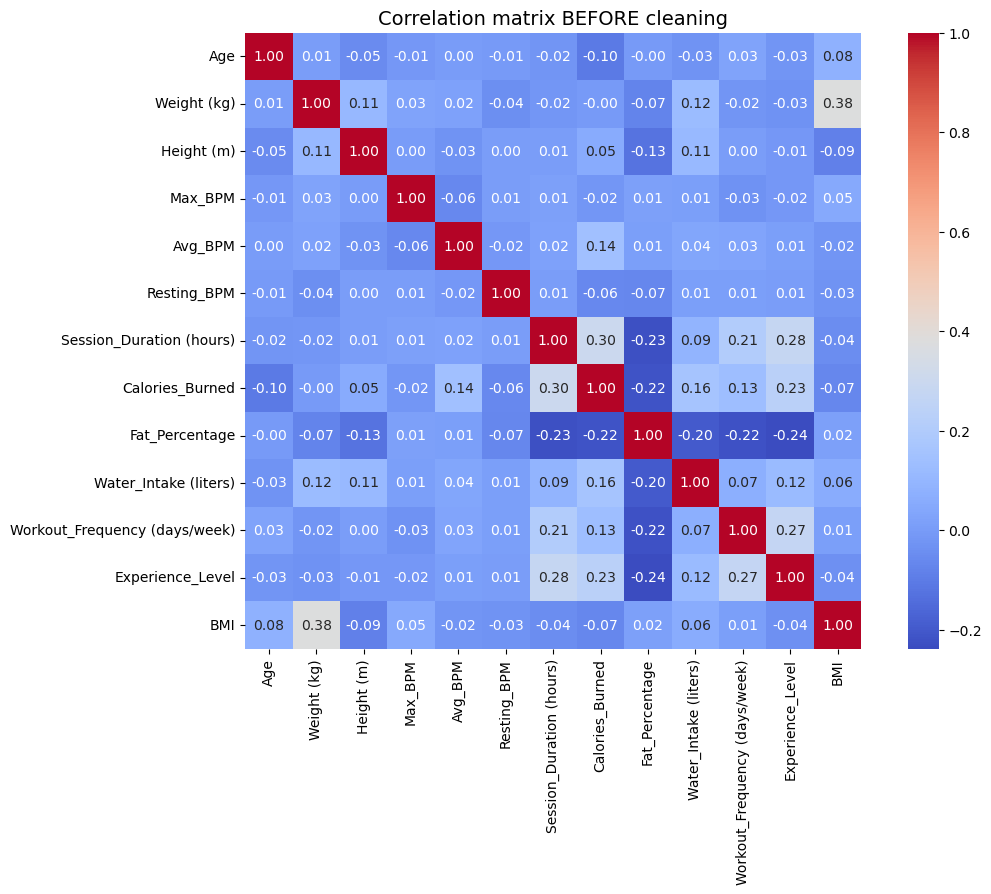

In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Select only the numeric columns
numeric_cols = df.select_dtypes(include=['number']).columns

# Calculate the correlation matrix
corr_matrix = df[numeric_cols].corr()

# Display the matrix as a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title("Correlation matrix BEFORE cleaning", fontsize=14)
plt.show()

### Interpretation of the correlation matrix


The correlations are generally weak, but several coherent relationships appear.

For example, weight is moderately related to BMI (0.38), which makes sense since BMI directly depends on weight. Workout duration also shows a positive correlation (0.30) with calories burned and, to a lesser extent, with experience level (0.28): more experienced individuals tend to train longer and burn more calories. Body fat percentage shows several negative correlations, notably with workout frequency (-0.24), session duration (-0.23), and calories burned (-0.22). This simply reflects that more regular or intense training is often associated with lower fat levels.

Hydration follows a similar trend, with slight positive links to calories burned and weight, which is consistent. The absence of strong correlations (all < 0.40) suggests that the risk of overtraining probably does not depend on a single variable but on a combination of factors.

Finally, Resting_BPM appears almost independent of the other variables (very low correlations), making it an interesting indicator to consider separately.

## Visualization of the distribution of each numerical variable


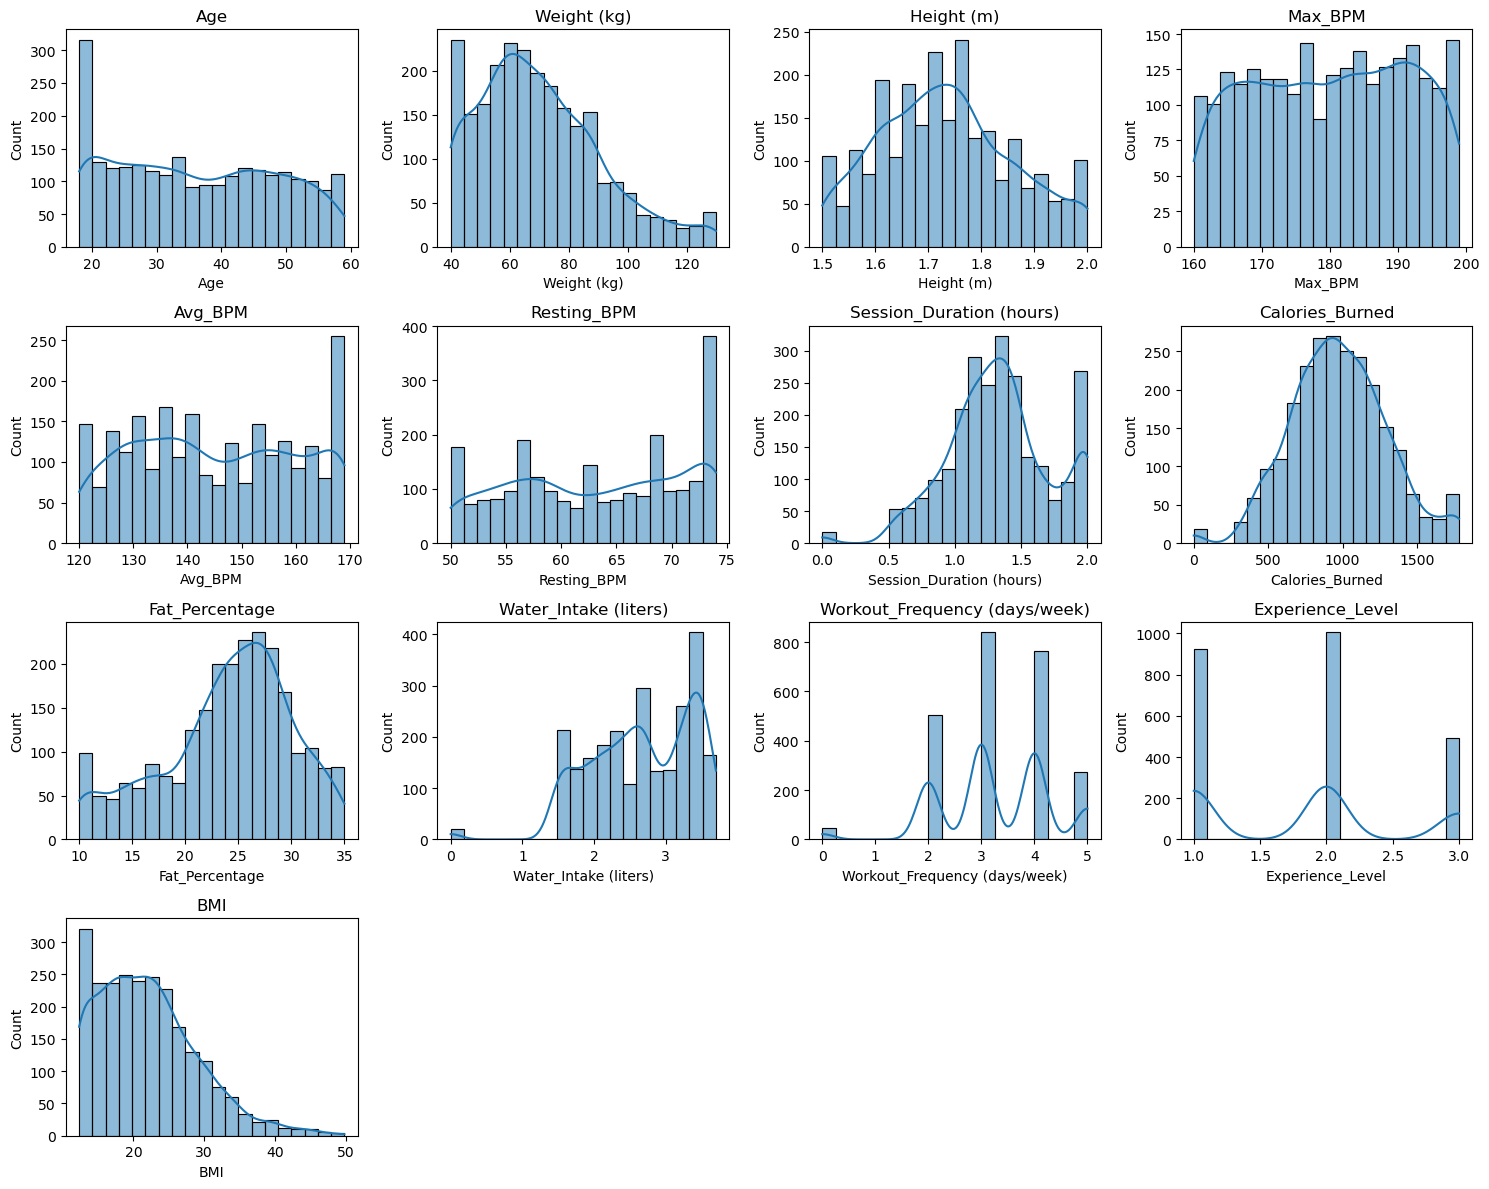

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = df.select_dtypes(include=['number']).columns

plt.figure(figsize=(15, 12))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(4, 4, i)
    sns.histplot(df[col], kde=True, bins=20)
    plt.title(col)
plt.tight_layout()
plt.show()

### Interpretation of the distribution of the variables

By looking at the histograms, most variables have a generally coherent distribution, but some show irregular shapes. This already suggests the possible presence of outliers in several columns.

- Variables like Weight, BMI, Workout_Frequency, Water_Intake, and Session_Duration show a fairly wide dispersion or asymmetrical distributions. This indicates that some individuals are clearly outside the usual values.
- In contrast, heart-related variables (Max_BPM, Avg_BPM, Resting_BPM) are much tighter and more regular, so they seem less affected by potential outliers.
- For Age, Fat_Percentage, and Height, the distribution remains well-centered around realistic values, without any particularly suspicious shape.
- Finally, Calories_Burned shows significant variability, which is logical given differences in workout intensity, although it may also include some extreme cases.

## Detection and treatment of outliers


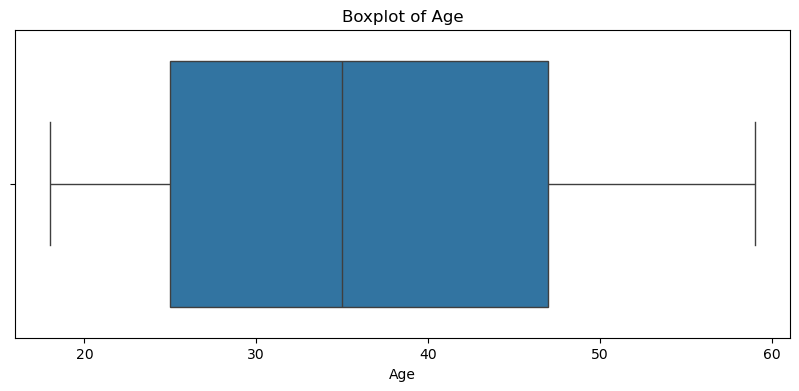

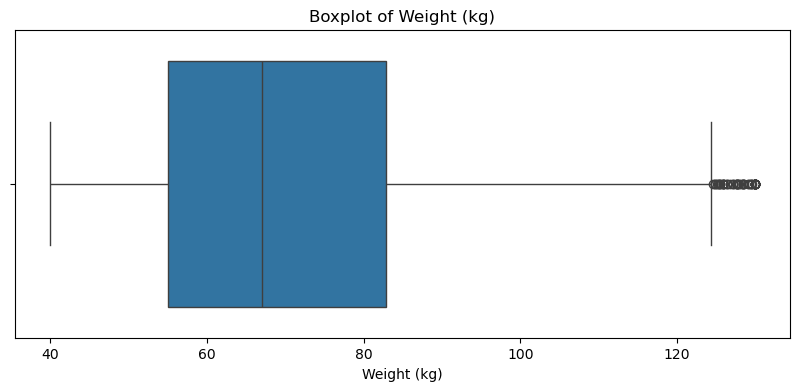

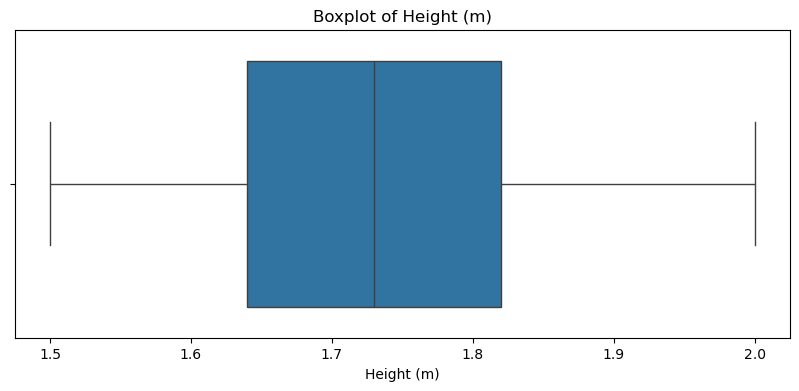

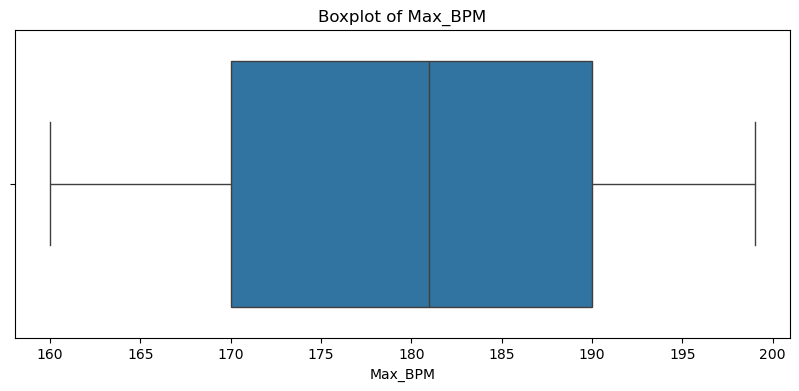

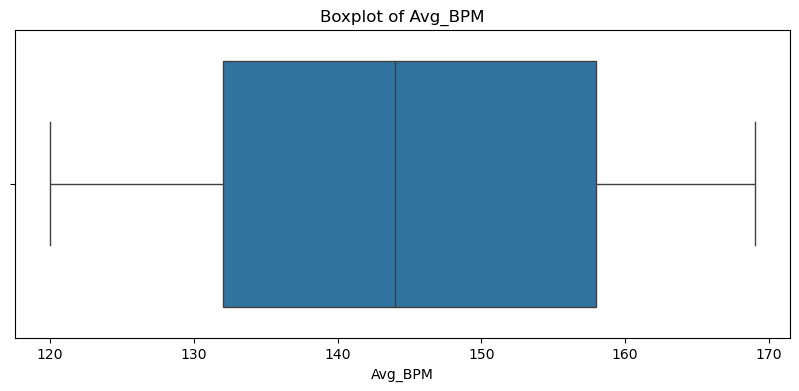

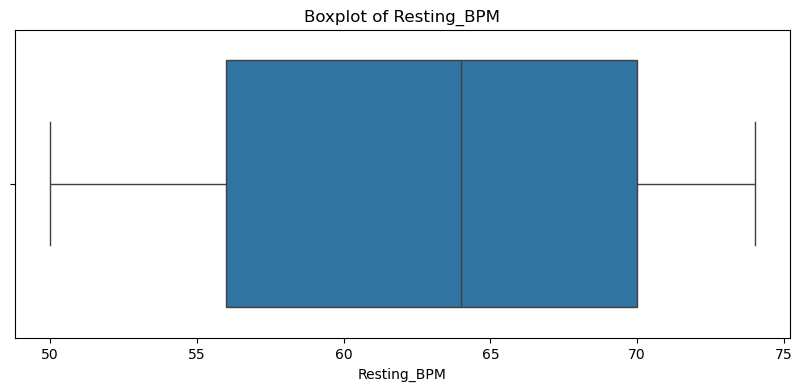

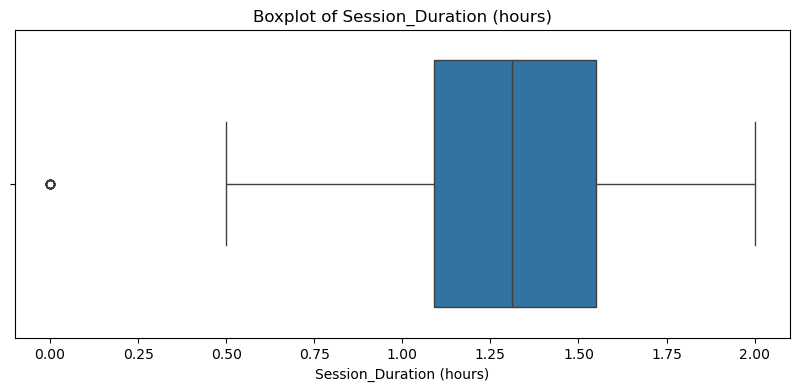

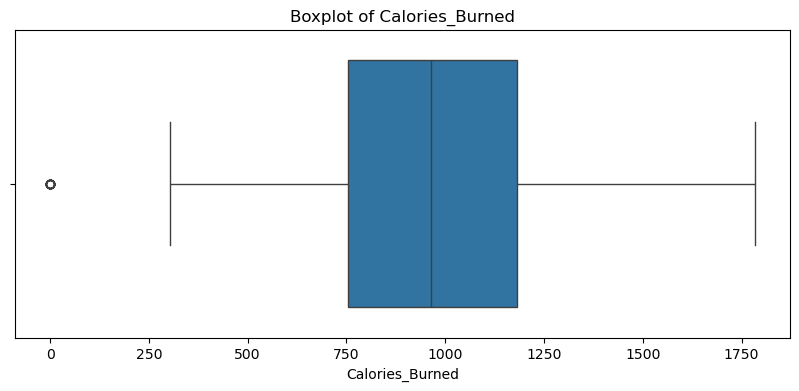

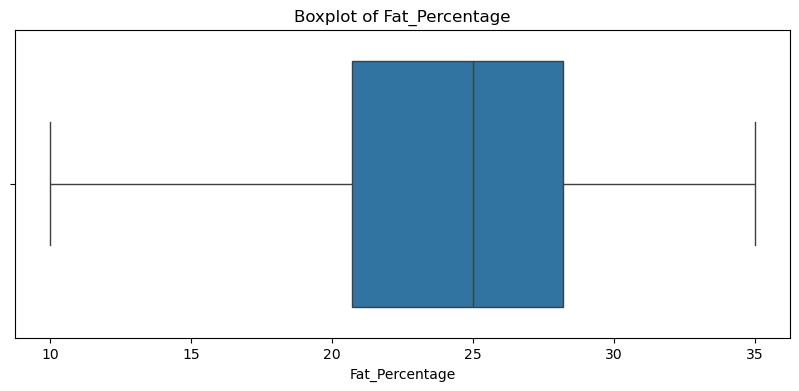

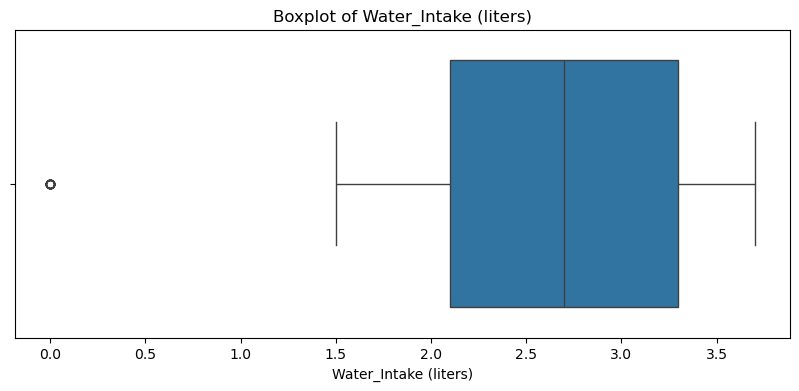

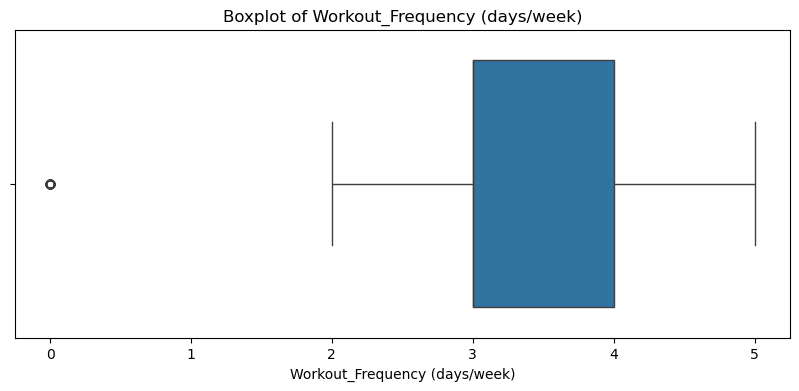

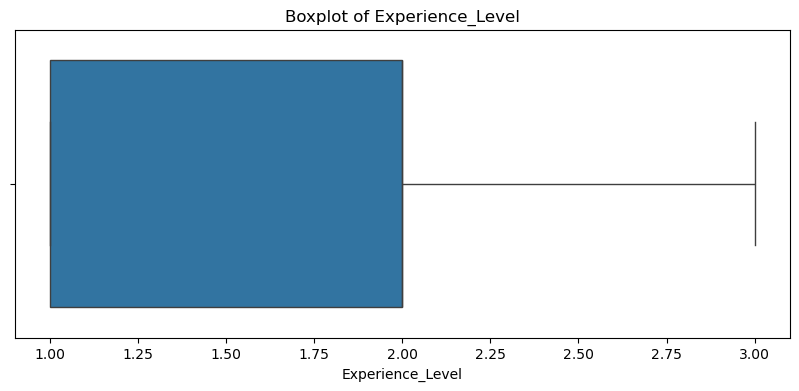

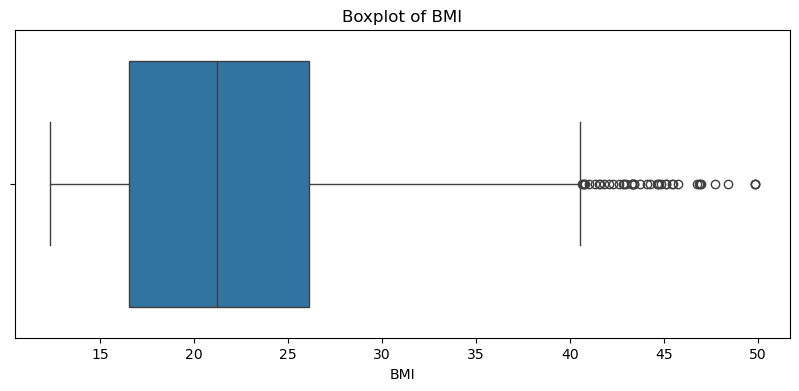

In [24]:
import seaborn as sns

def afficher_outliers(df):
    for col in df.select_dtypes(include='number').columns:
        plt.figure(figsize=(10, 4))
        sns.boxplot(data=df, x=col)
        plt.title(f"Boxplot of {col}")
        plt.show()

afficher_outliers(df)

### Displaying the number of outliers per column


In [25]:
for col in df.select_dtypes(include='number').columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers")

Age: 0 outliers
Weight (kg): 46 outliers
Height (m): 0 outliers
Max_BPM: 0 outliers
Avg_BPM: 0 outliers
Resting_BPM: 0 outliers
Session_Duration (hours): 18 outliers
Calories_Burned: 19 outliers
Fat_Percentage: 0 outliers
Water_Intake (liters): 21 outliers
Workout_Frequency (days/week): 47 outliers
Experience_Level: 0 outliers
BMI: 41 outliers


**Interpretation**

The results show that some variables have a significant number of extreme values. Weight, BMI, Workout_Frequency, Water_Intake, and Session_Duration are the most affected columns, which confirms what was already observed in the histograms: the variability was unusual.

In contrast, physiological variables such as Age, Height, Max_BPM, Avg_BPM, Resting_BPM, Fat_Percentage, and Experience_Level do not appear to contain outliers according to the IQR method.

We can therefore say that anomalies are mainly concentrated in variables related to training behavior (frequency, duration, hydration) and body metrics. These are the ones that will need to be treated before applying models.


### Replacing outliers with the median


In [26]:
def traiter_outliers_iteratif(df, colonnes):
    """
    Iteratively handle outliers by replacing them with the median
    until there are none left
    """
    df_clean = df.copy()
    
    for col in colonnes:
        iteration = 0
        while True:
            iteration += 1
            # Recalculate Q1, Q3, IQR at EACH iteration
            Q1 = df_clean[col].quantile(0.25)
            Q3 = df_clean[col].quantile(0.75)
            IQR = Q3 - Q1
            lower = Q1 - 1.5 * IQR
            upper = Q3 + 1.5 * IQR
            
            # Identify the outliers
            outliers_mask = (df_clean[col] < lower) | (df_clean[col] > upper)
            n_outliers = outliers_mask.sum()
            
            if n_outliers == 0:
                print(f" {col}: {iteration} iteration(s)")
                break  # No more outliers, we stop
            
            #  Replace with the CURRENT median (recalculated)
            median = df_clean[col].median()
            df_clean.loc[outliers_mask, col] = median
    
    return df_clean

# Application
cols_numeriques = df.select_dtypes(include='number').columns
df= traiter_outliers_iteratif(df, cols_numeriques)

 Age: 1 iteration(s)
 Weight (kg): 4 iteration(s)
 Height (m): 1 iteration(s)
 Max_BPM: 1 iteration(s)
 Avg_BPM: 1 iteration(s)
 Resting_BPM: 1 iteration(s)
 Session_Duration (hours): 2 iteration(s)
 Calories_Burned: 2 iteration(s)
 Fat_Percentage: 1 iteration(s)
 Water_Intake (liters): 2 iteration(s)
 Workout_Frequency (days/week): 2 iteration(s)
 Experience_Level: 1 iteration(s)
 BMI: 5 iteration(s)


**Why choose the median?**

I chose to replace outliers with the median rather than remove them for two main reasons. First, this allows us to retain all observations without reducing the dataset size, which is important for maintaining the statistical power of analyses. Second, the median is a robust measure that is not influenced by extreme values, unlike the mean. By replacing outliers with the median of each variable, we bring these aberrant values closer to a typical, representative value of the distribution without introducing bias.

## Post-cleaning Visualizations

### Correlation Matrix

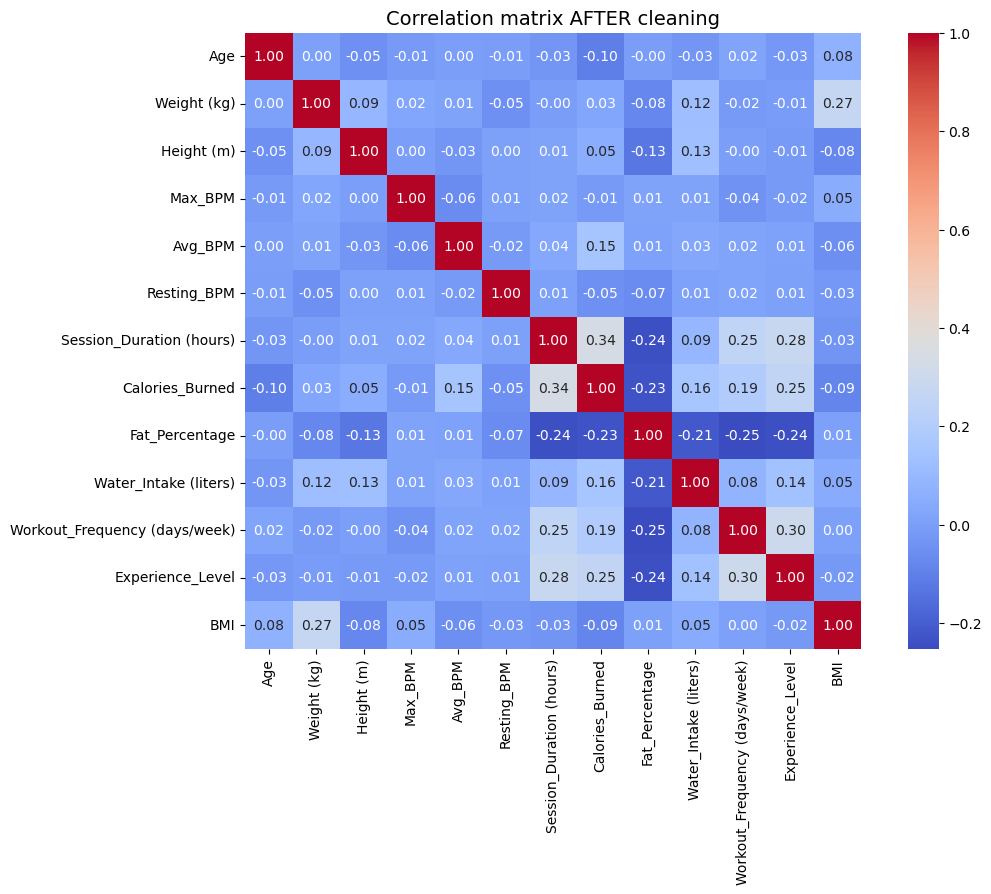

,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
Age,1.000000,0.003311,-0.050396,-0.012728,0.000126,-0.005157,-0.030391,-0.103951,-0.002833,-0.031781,0.018497,-0.025102,0.075300
Weight (kg),0.003311,1.000000,0.091315,0.024256,0.013863,-0.048654,-0.002923,0.025127,-0.077334,0.123654,-0.016807,-0.010152,0.270127
Height (m),-0.050396,0.091315,1.000000,0.002041,-0.028174,0.004488,0.014257,0.053052,-0.125790,0.127939,-0.002312,-0.013451,-0.078430
Max_BPM,-0.012728,0.024256,0.002041,1.000000,-0.063405,0.007041,0.015367,-0.013142,0.014604,0.014735,-0.040831,-0.015297,0.051215
Avg_BPM,0.000126,0.013863,-0.028174,-0.063405,1.000000,-0.015394,0.035797,0.152429,0.011642,0.028599,0.018563,0.011012,-0.055436
Resting_BPM,-0.005157,-0.048654,0.004488,0.007041,-0.015394,1.000000,0.005057,-0.050678,-0.065151,0.008757,0.018642,0.006038,-0.026653
Session_Duration (hours),-0.030391,-0.002923,0.014257,0.015367,0.035797,0.005057,1.000000,0.337888,-0.239746,0.092156,0.251129,0.280498,-0.034593
Calories_Burned,-0.103951,0.025127,0.053052,-0.013142,0.152429,-0.050678,0.337888,1.000000,-0.230493,0.157746,0.192276,0.252064,-0.085051
Fat_Percentage,-0.002833,-0.077334,-0.125790,0.014604,0.011642,-0.065151,-0.239746,-0.230493,1.000000,-0.214512,-0.251845,-0.238257,0.006359
Water_Intake (liters),-0.031781,0.123654,0.127939,0.014735,0.028599,0.008757,0.092156,0.157746,-0.214512,1.000000,0.079549,0.135106,0.046249


In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Select only the numerical columns
numeric_cols = df.select_dtypes(include=['number']).columns

# Calculate the correlation matrix
corr_matrix = df[numeric_cols].corr()

# Display the matrix as a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title("Correlation matrix AFTER cleaning", fontsize=14)
plt.show()
corr_matrix

**Interpretation**

After cleaning the dataset, the correlation matrix remains generally consistent and confirms the trends observed before processing. The relationships between training-related variables, such as session duration, calories burned, weekly frequency, and experience level, are still present, showing that these dimensions evolve together logically. Overall, the cleaning did not alter the structure of the dataset: it mainly made the correlations more realistic by removing the effects of outliers while preserving the main relationships between variables related to physical activity.

### Boxplots

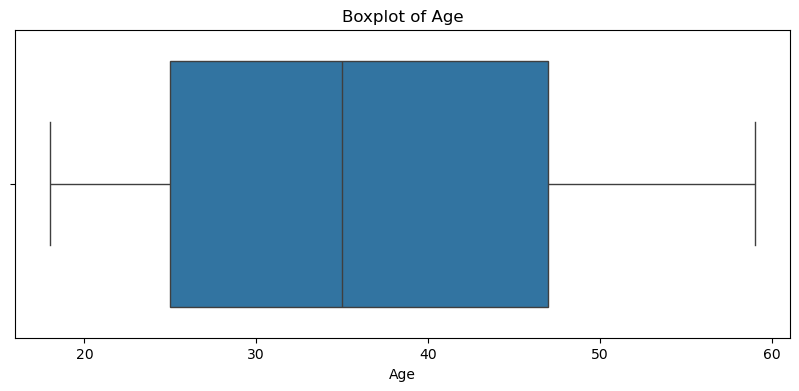

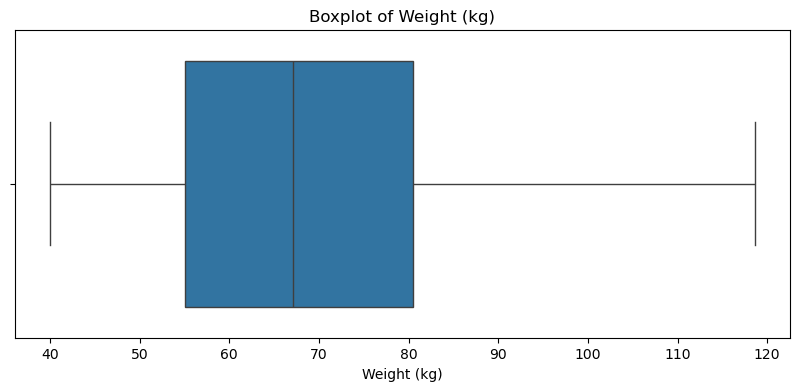

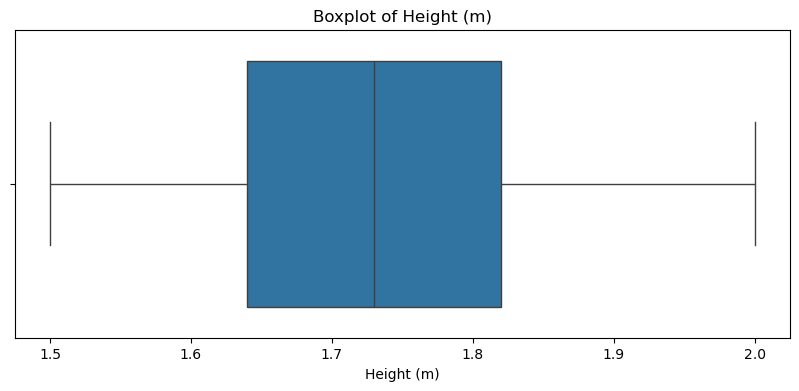

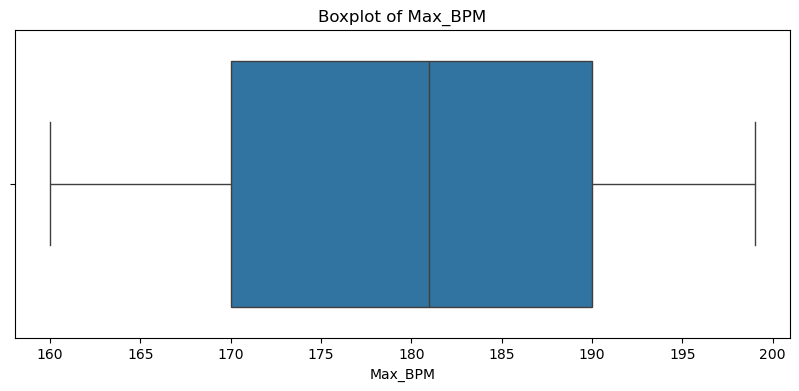

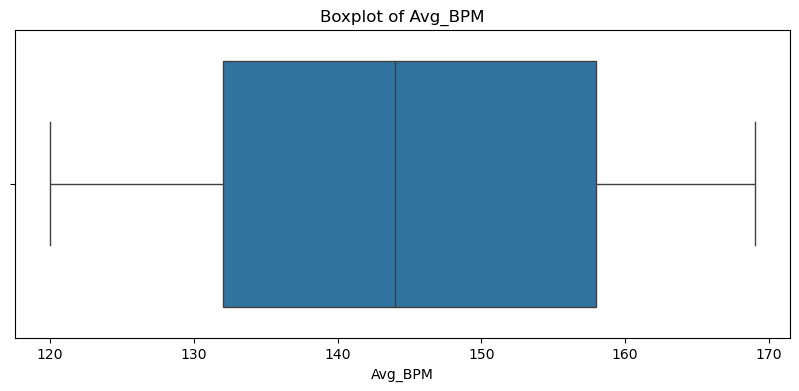

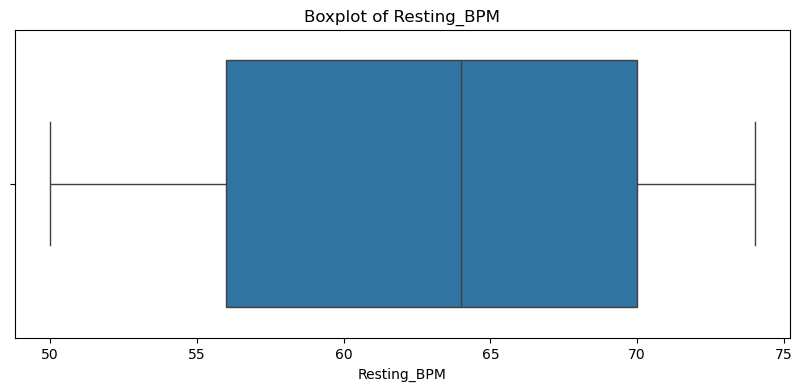

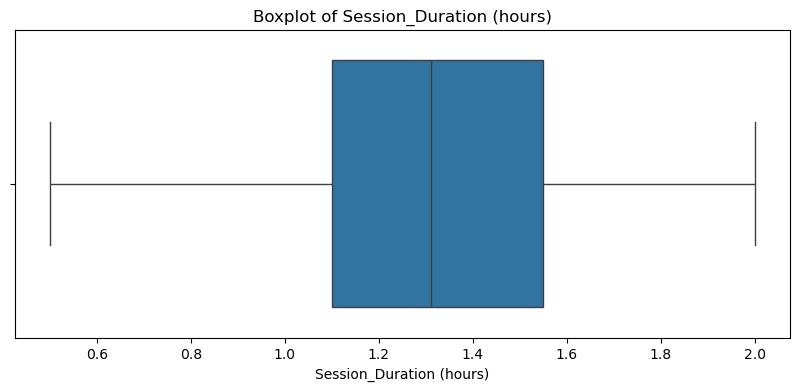

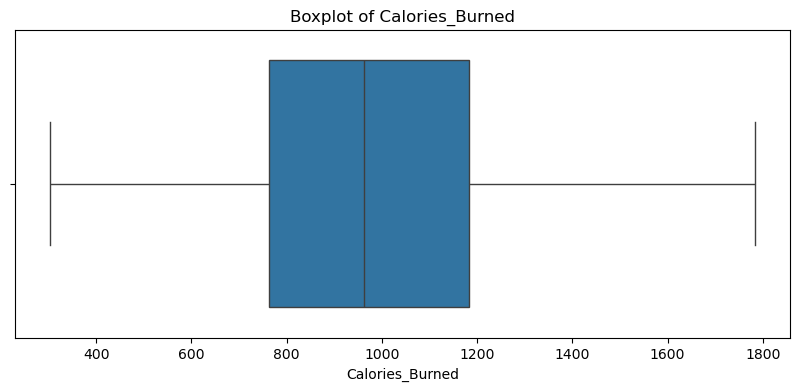

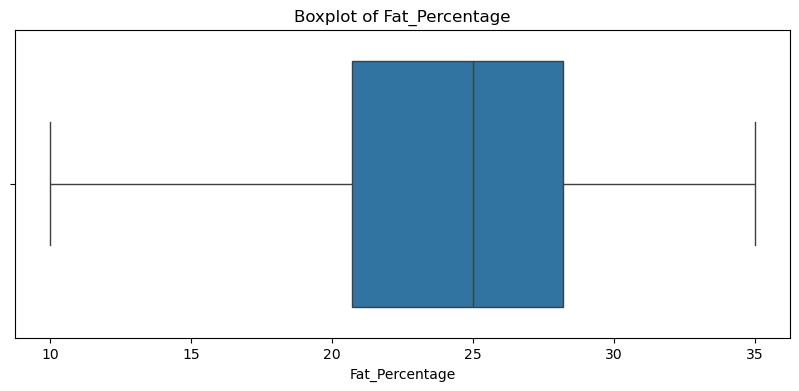

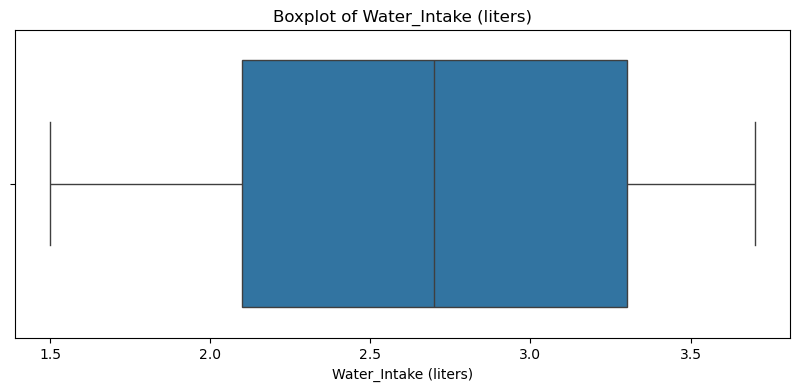

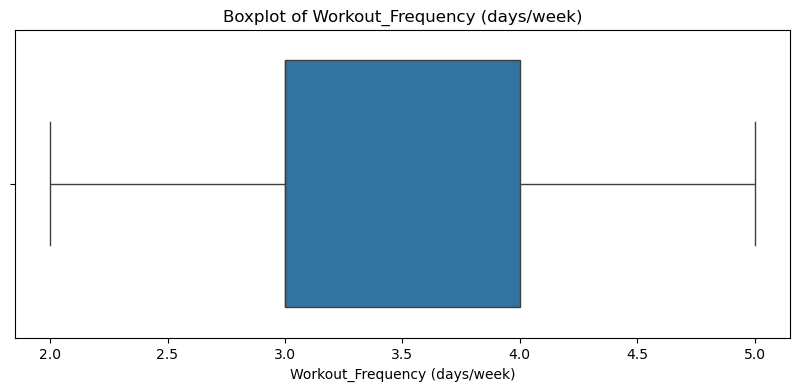

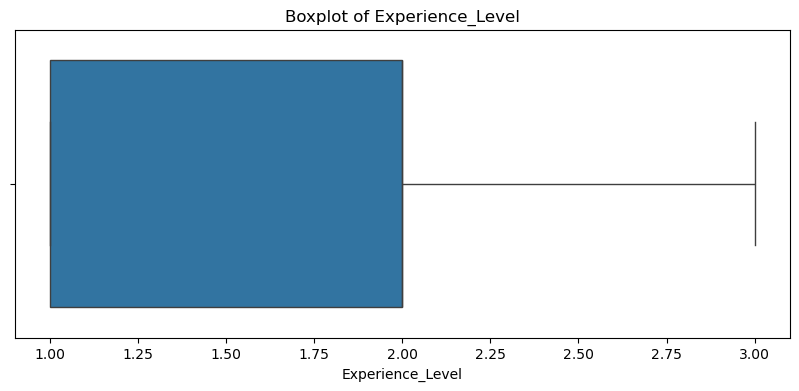

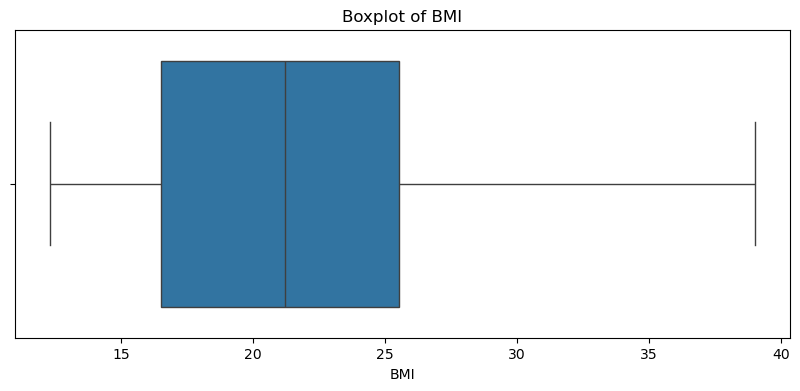

In [28]:
import seaborn as sns

def afficher_outliers(df):
    for col in df.select_dtypes(include='number').columns:
        plt.figure(figsize=(10, 4))
        sns.boxplot(data=df, x=col)
        plt.title(f"Boxplot of {col}")
        plt.show()

afficher_outliers(df)

In [29]:
for col in df.select_dtypes(include='number').columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers")
df

Age: 0 outliers
Weight (kg): 0 outliers
Height (m): 0 outliers
Max_BPM: 0 outliers
Avg_BPM: 0 outliers
Resting_BPM: 0 outliers
Session_Duration (hours): 0 outliers
Calories_Burned: 0 outliers
Fat_Percentage: 0 outliers
Water_Intake (liters): 0 outliers
Workout_Frequency (days/week): 0 outliers
Experience_Level: 0 outliers
BMI: 0 outliers


,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2768,54,Male,88.5,2.00,173,134,58,1.11,1388.0,HIIT,27.7,3.7,3,2,36.73
2769,52,Male,84.3,1.69,164,169,54,0.77,1367.0,HIIT,32.6,2.9,3,2,15.11
2770,47,Male,70.1,1.84,188,129,67,1.20,1261.0,Strength,28.4,2.5,3,2,17.99
2771,35,Male,49.3,1.71,180,152,73,1.04,956.0,Cardio,32.9,1.7,4,3,12.65


### Cleaned Data Distributions

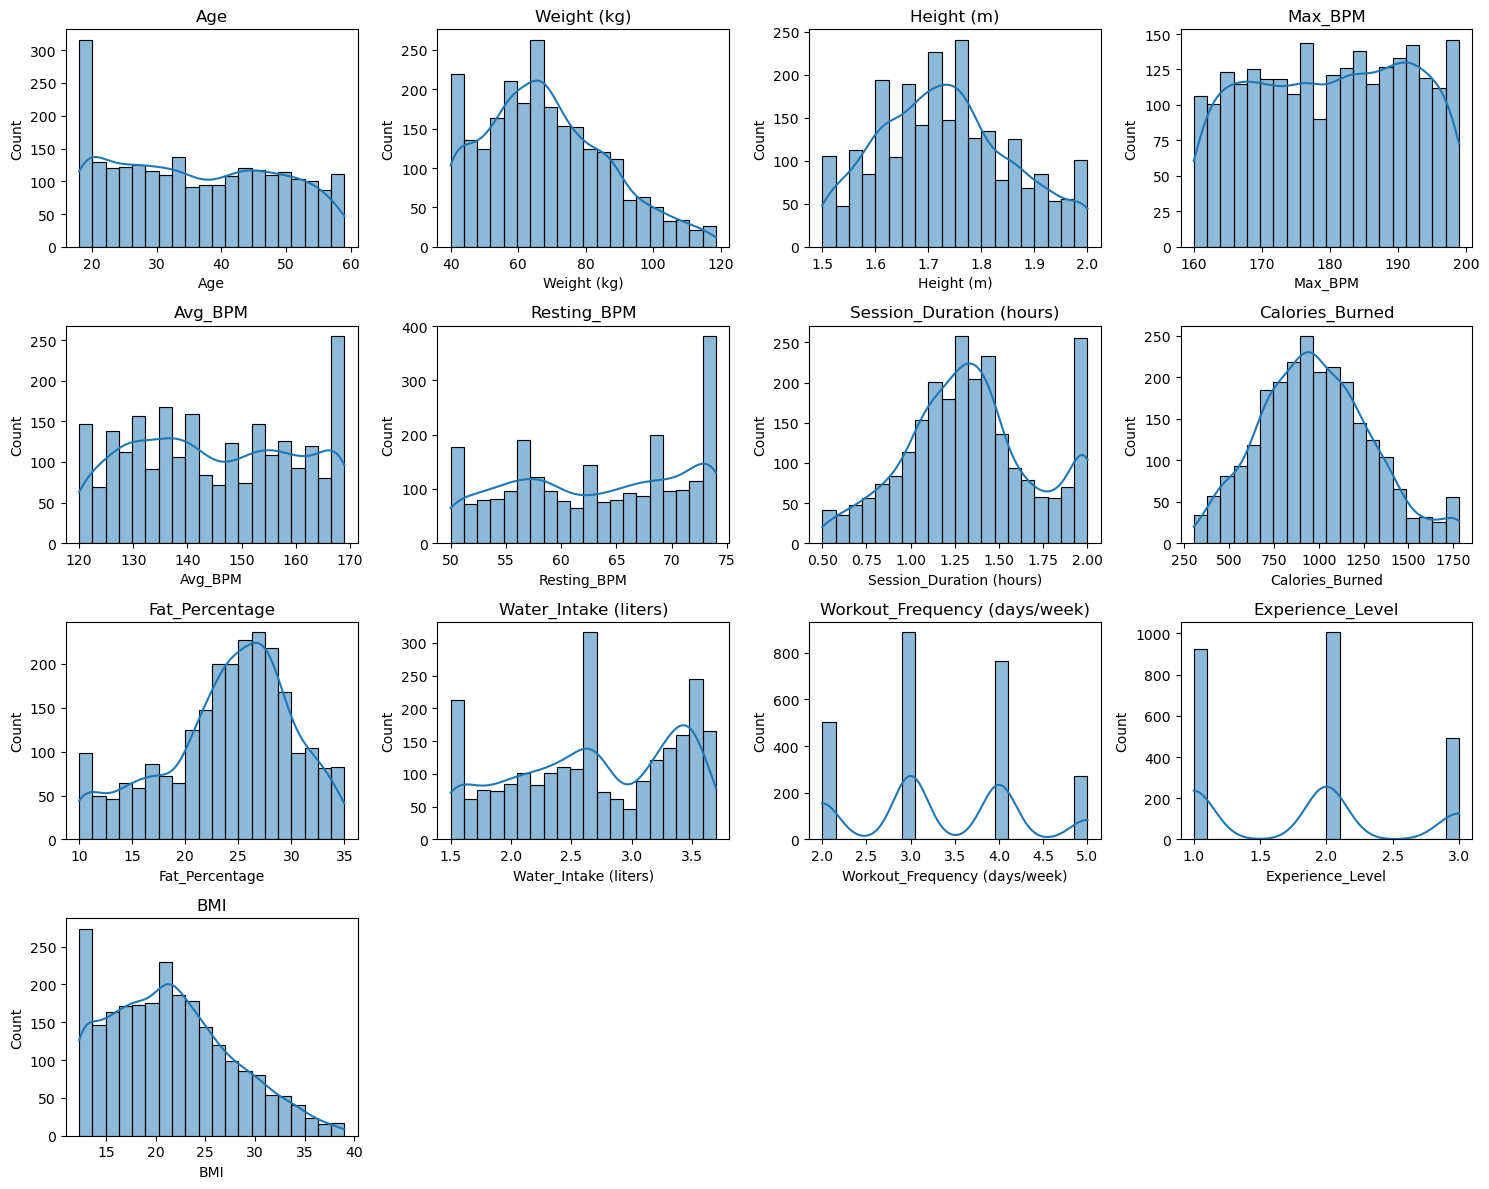

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = df.select_dtypes(include=['number']).columns

plt.figure(figsize=(15, 12))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(4, 4, i)
    sns.histplot(df[col], kde=True, bins=20)
    plt.title(col)
plt.tight_layout()
plt.show()

**Interpretation**

By looking at the histograms after cleaning, we can see that replacing outliers with the median worked well. The distributions are now much more regular and symmetrical, especially for Weight, BMI, Session_Duration, and Calories_Burned, which previously had irregular shapes and high dispersion. Heart-related variables remain well-centered and are now even more homogeneous than before. Overall, the data is now well-cleaned without any loss of observations.

In [31]:
df_clean = df

In [32]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2427 entries, 0 to 2772
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            2427 non-null   int64  
 1   Gender                         2427 non-null   object 
 2   Weight (kg)                    2427 non-null   float64
 3   Height (m)                     2427 non-null   float64
 4   Max_BPM                        2427 non-null   int64  
 5   Avg_BPM                        2427 non-null   int64  
 6   Resting_BPM                    2427 non-null   int64  
 7   Session_Duration (hours)       2427 non-null   float64
 8   Calories_Burned                2427 non-null   float64
 9   Workout_Type                   2427 non-null   object 
 10  Fat_Percentage                 2427 non-null   float64
 11  Water_Intake (liters)          2427 non-null   float64
 12  Workout_Frequency (days/week)  2427 non-null   int64 

**Observation**

The cleaning process reduced the dataset from 2,773 to 2,427 observations, a loss of 346 rows (about 12.5%). This reduction is mainly due to the removal of rows containing inconsistent values, such as zeros in Age, Weight, Height, or Experience_Level, as well as handling missing values in Gender and Workout_Type. Now, all columns have exactly 2,427 non-null values, confirming that there are no more missing data.

In [33]:
df_clean.describe()

,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
count,2427.000000,2427.000000,2427.000000,2427.000000,2427.000000,2427.000000,2427.000000,2427.000000,2427.000000,2427.000000,2427.000000,2427.000000,2427.000000
mean,36.194479,68.396044,1.732093,180.096415,145.100124,63.213020,1.336601,982.997940,24.048620,2.688175,3.331685,1.821590,21.451801
std,12.417514,18.282092,0.125736,11.486711,14.955232,7.727396,0.366412,311.240237,6.078033,0.665252,0.928613,0.744241,6.201544
min,18.000000,40.000000,1.500000,160.000000,120.000000,50.000000,0.500000,303.000000,10.000000,1.500000,2.000000,1.000000,12.320000
25%,25.000000,55.050000,1.640000,170.000000,132.000000,56.000000,1.100000,762.000000,20.700000,2.100000,3.000000,1.000000,16.520000
50%,35.000000,67.100000,1.730000,181.000000,144.000000,64.000000,1.310000,963.000000,25.000000,2.700000,3.000000,2.000000,21.200000
75%,47.000000,80.500000,1.820000,190.000000,158.000000,70.000000,1.550000,1182.500000,28.200000,3.300000,4.000000,2.000000,25.515000
max,59.000000,118.600000,2.000000,199.000000,169.000000,74.000000,2.000000,1783.000000,35.000000,3.700000,5.000000,3.000000,38.990000


**Observation**

The minimum values have become realistic: the minimum age is now 18 years (instead of 0), weight starts at 40 kg, height at 1.50 m, and Experience_Level correctly starts at 1. Replacing outliers with the median has also tightened the distributions, which is reflected in slightly reduced standard deviations for some variables like Weight and BMI.

The mean values have remained largely stable, indicating that the cleaning did not bias the dataset but simply corrected anomalies. The value ranges (min–max) are now consistent and suitable for modeling. The dataset is now clean, complete, and ready for analysis.


In [34]:
df_clean

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2768,54,Male,88.5,2.00,173,134,58,1.11,1388.0,HIIT,27.7,3.7,3,2,36.73
2769,52,Male,84.3,1.69,164,169,54,0.77,1367.0,HIIT,32.6,2.9,3,2,15.11
2770,47,Male,70.1,1.84,188,129,67,1.20,1261.0,Strength,28.4,2.5,3,2,17.99
2771,35,Male,49.3,1.71,180,152,73,1.04,956.0,Cardio,32.9,1.7,4,3,12.65


## Creation of the Target Variable: Overtraining Risk

### Objective

Create a binary column `Overtraining_Risk` (0 = low risk, 1 = high risk) based on scientific reference values to assess whether an individual shows signs of overtraining.

### Methodology

#### Step 1: Construct Reference Data

We created tables of normal values adjusted for age and sex, based on recognized medical sources:

**Sources used:**

* **Resting heart rate:** American Heart Association (AHA) 2024, National Institutes of Health (NIH) 2023
* **Body fat percentage:** American Council on Exercise (ACE) 2024
* **Maximum heart rate:** Tanaka formula, Journal of the American College of Cardiology (JACC) 2001
* **Body Mass Index (BMI):** World Health Organization (WHO) 2024

#### Step 2: Risk Score Calculation

For each individual, we calculate a risk score based on multiple physiological indicators:

1. **High resting heart rate:** A resting BPM above normal for age indicates physiological stress (primary indicator of overtraining)

2. **Low heart rate reserve:** Difference between max HR and resting HR < expected thresholds (sign of cardiovascular fatigue)

3. **Imbalanced body composition:**

   * Too low body fat (< essential threshold) → compromised recovery
   * Too high body fat (> obesity threshold) → metabolic stress

4. **Excessive training load:** Frequency × session duration too high

5. **Prolonged session duration:** Sessions > 2h increase fatigue risk

6. **Insufficient hydration:** Water intake < 2L compromises recovery

7. **Abnormal BMI:** Underweight or obesity amplifies physiological stress

8. **Low caloric efficiency:** Calories burned per hour < thresholds → sign of fatigue

9. **Experience level:** Beginners are more vulnerable

#### Step 3: Final Classification

* **Risk score ≥ 7** → `Overtraining_Risk = 1` (HIGH risk)
* **Risk score 4–6** → `Overtraining_Risk = 1` (MODERATE risk)
* **Risk score < 4** → `Overtraining_Risk = 0` (LOW risk)

---

### Full References

1. **American Heart Association (AHA).** "Target Heart Rates Chart." 2024.
   [https://www.heart.org/en/healthy-living/fitness/fitness-basics/target-heart-rates](https://www.heart.org/en/healthy-living/fitness/fitness-basics/target-heart-rates)

2. **National Institutes of Health (NIH).** "Resting Heart Rate Reference Data." National Health Statistics Reports. 2023.

3. **American Council on Exercise (ACE).** "Body Fat Percentage Norms." 2024.

4. **Tanaka H, Monahan KD, Seals DR.** "Age-predicted maximal heart rate revisited."
   Journal of the American College of Cardiology. 2001;37(1):153-156.

5. **World Health Organization (WHO).** "BMI Classification." 2024.

In [35]:
df_clean.Age.min(), df.Age.max()

(18, 59)

In [36]:
ages = df_clean.Age.unique()
ages.sort()
ages

array([18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51,
       52, 53, 54, 55, 56, 57, 58, 59])

In [37]:
# ============================================================================

# REFERENCES: Normal values by age and sex

# Sources: AHA 2024, NIH 2023, ACE 2024

# ============================================================================

# 1. Resting heart rate (BPM) by age

resting_hr_reference = pd.DataFrame({
    'Age_Min': [18, 26, 36, 46, 56, 66],
    'Age_Max': [25, 35, 45, 55, 65, 100],
    'Normal_Min': [60, 61, 62, 63, 64, 65],
    'Normal_Max': [80, 80, 81, 82, 83, 84],
    'Athlete_Min': [40, 41, 42, 43, 44, 45],
    'Athlete_Max': [54, 55, 56, 57, 58, 60]
})

# 2. Body fat percentage (Body Fat %) by sex and age
body_fat_reference = pd.DataFrame({
    'Sexe': ['Male', 'Male', 'Male', 'Male', 'Female', 'Female', 'Female', 'Female'],
    'Age_Min': [18, 30, 40, 50, 18, 30, 40, 50],
    'Age_Max': [29, 39, 49, 100, 29, 39, 49, 100],
    'Essentiel_Max': [5, 5, 5, 5, 13, 13, 13, 13],
    'Athlète_Min': [6, 6, 7, 8, 14, 15, 16, 17],
    'Athlète_Max': [13, 14, 15, 16, 21, 22, 23, 24],
    'Fitness_Max': [17, 18, 19, 20, 25, 26, 27, 28],
    'Acceptable_Max': [24, 25, 26, 27, 31, 32, 33, 34],
    'Obésité_Seuil': [25, 26, 27, 28, 32, 33, 34, 35]
})

# 3. Theoretical maximum heart rate (Tanaka et al. formula, JACC 2001)
def get_max_hr_expected(age):
    return 208 - (0.7 * age)

# 4. Reference BMI according to WHO 2024
bmi_reference = {
    'Maigreur': 18.5,
    'Normal': 24.9,
    'Surpoids': 29.9,
    'Obésité classe I': 34.9,
    'Obésité classe II': 39.9,
    'Obésité classe III': 40.0
}

In [38]:
def get_resting_hr_range(age):
    """Obtain the normal resting heart rate range for age as a parameter"""
    ref = resting_hr_reference[
        (resting_hr_reference['Age_Min'] <= age) & 
        (resting_hr_reference['Age_Max'] >= age)
    ]
    if len(ref) > 0:
        return ref.iloc[0]['Normal_Min'], ref.iloc[0]['Normal_Max']
    
    # If the age is not found in the reference table
    if age < 18:
        return 70, 100
    elif age > 100:
        return 65, 100

def get_body_fat_range(age, gender):
    """Get normal body fat range for age and gender"""
    ref = body_fat_reference[
        (body_fat_reference['Sexe'] == gender) &
        (body_fat_reference['Age_Min'] <= age) & 
        (body_fat_reference['Age_Max'] >= age)
    ]
    if len(ref) > 0:
        return (ref.iloc[0]['Essentiel_Max'], ref.iloc[0]['Acceptable_Max'], ref.iloc[0]['Obésité_Seuil'])
    
    if gender == 'Male':
        return 5, 21, 28
    else :
        return 13, 20, 32

In [39]:
def calculate_overtraining_risk(row):
    """
    Calculates the overtraining risk based on reference values adjusted for age and sex
    Returns: risk_score (int), risk_level (str), details (dict)
    """

    risk_score = 0
    details = {}
    
    age = row['Age']
    gender = row['Gender']
    
    # -------------------------------------------------------------------------
    # 1. ANALYSIS OF RESTING BPM
    # -------------------------------------------------------------------------
    hr_min, hr_max = get_resting_hr_range(age)
    resting_bpm = row['Resting_BPM']
    
    if resting_bpm > hr_max + 10:
        risk_score += 3  # # Severely elevated
        details['Resting_HR'] = f"Severely elevated ({resting_bpm} vs normal {hr_min}-{hr_max})"
    elif resting_bpm > hr_max + 5:
        risk_score += 2  ## Moderately elevated
        details['Resting_HR'] = f"Elevated ({resting_bpm} vs normal {hr_min}-{hr_max})"
    elif resting_bpm > hr_max:
        risk_score += 1  # # Slightly elevated
        details['Resting_HR'] = f"Slightly elevated ({resting_bpm} vs normal {hr_min}-{hr_max})"
    else:
        details['Resting_HR'] = "Normal"
    
    # -------------------------------------------------------------------------
    # 2. BPM RESERVE (Max BPM - Resting BPM)
    # -------------------------------------------------------------------------
    expected_max_hr = get_max_hr_expected(age)
    hr_reserve = row['Max_BPM'] - row['Resting_BPM']
    expected_reserve = expected_max_hr - hr_max
    
    # A low heart rate reserve indicates poor cardiovascular fitness or overtraining
    if hr_reserve < expected_reserve * 0.7:  # Moins que 70% attendu
        risk_score += 2
        details['HR_Reserve'] = f"Low reserve ({hr_reserve} vs expected ~{expected_reserve})"
    elif hr_reserve < expected_reserve * 0.85:
        risk_score += 1
        details['HR_Reserve'] = f"Below average ({hr_reserve} vs expected ~{expected_reserve})"
    else:
        details['HR_Reserve'] = "Adequate"
    
    # -------------------------------------------------------------------------
    # 3.  BODY FAT PERCENTAGE 
    # -------------------------------------------------------------------------
    essential, normal, high = get_body_fat_range(age, gender)
    fat_pct = row['Fat_Percentage']
    
    if fat_pct < essential:
        risk_score += 2  # Too low - hormonal issues, poor recovery
        details['Body_Fat'] = f"Dangerously low ({fat_pct}% vs min {essential}%)"
    elif fat_pct > high:
        risk_score += 1  # Too high - metabolic stress
        details['Body_Fat'] = f"High ({fat_pct}% vs normal max {normal}%)"
    elif fat_pct > normal:
        risk_score += 0.5
        details['Body_Fat'] = f"Above normal ({fat_pct}% vs normal max {normal}%)"
    else:
        details['Body_Fat'] = "Normal range"
    
    # -------------------------------------------------------------------------
    # 4. TRAINING VOLUME (Frequency * Duration)
    # -------------------------------------------------------------------------
    workout_freq = row['Workout_Frequency (days/week)']
    session_duration = row['Session_Duration (hours)']
    training_load = workout_freq * session_duration
    
    if training_load > 12:  # ex: 6j * 2h
        risk_score += 3
        details['Training_Load'] = f"Excessive ({training_load:.1f} hrs/week)"
    elif training_load > 10:
        risk_score += 2
        details['Training_Load'] = f"Very high ({training_load:.1f} hrs/week)"
    elif training_load > 8:
        risk_score += 1
        details['Training_Load'] = f"High ({training_load:.1f} hrs/week)"
    else:
        details['Training_Load'] = "Moderate"
    
    # A single very long session
    if session_duration > 2.5:
        risk_score += 1
        details['Session_Duration'] = f"Very long sessions ({session_duration} hrs)"
    elif session_duration > 2.0:
        risk_score += 0.5
        details['Session_Duration'] = f"Long sessions ({session_duration} hrs)"
    
    # -------------------------------------------------------------------------
    # 5. # RECOVERY INDICATORS
    # -------------------------------------------------------------------------
    # Water
    water_intake = row['Water_Intake (liters)']
    if water_intake < 2.0:
        risk_score += 1
        details['Hydration'] = f"Low water intake ({water_intake}L)"
    elif water_intake < 2.5:
        risk_score += 0.5
        details['Hydration'] = f"Suboptimal hydration ({water_intake}L)"
    else:
        details['Hydration'] = "Adequate"
    
    # -------------------------------------------------------------------------
    # 6. EXPERIENCE LEVEL
    # -------------------------------------------------------------------------
    experience = row['Experience_Level']
    
    # Beginners are more likely to experience overtraining
    if experience == 1:  # Beginner
        risk_score *= 1.3  # Increase in risk by 30%
        details['Experience'] = "Beginner (higher susceptibility)"
    elif experience == 2:  # Intermediate
        risk_score *= 1.1  # Increase BY 10%
        details['Experience'] = "Intermediate"
    else:  # ADVANCED
        details['Experience'] = "Advanced"
    
    # -------------------------------------------------------------------------
    # 7. CONSIDERATION OF BMI (according to WHO 2024)
    # -------------------------------------------------------------------------
    bmi = row['BMI']

    # Underweight
    if bmi < bmi_reference['Maigreur']:
        risk_score += 2  # High risk: compromised recovery, energy deficit
        details['BMI'] = f"Maigreur ({bmi:.1f}, norme < {bmi_reference['Maigreur']})"

    # Normal (no penalty)
    elif bmi <= bmi_reference['Normal']:
        details['BMI'] = f"Normal ({bmi:.1f})"

    # Overweight (slight risk)
    elif bmi <= bmi_reference['Surpoids']:
        risk_score += 1  # Increased metabolic and joint load
        details['BMI'] = f"Surpoids ({bmi:.1f}, norme {bmi_reference['Normal']}-{bmi_reference['Surpoids']})"

    # Class I obesity (moderate risk)
    elif bmi <= bmi_reference['Obésité classe I']:
        risk_score += 2
        details['BMI'] = f"Obésité classe I ({bmi:.1f}, norme {bmi_reference['Surpoids']}-{bmi_reference['Obésité classe I']})"

    # Class II obesity (high risk)
    elif bmi <= bmi_reference['Obésité classe II']:
        risk_score += 3
        details['BMI'] = f"Obésité classe II ({bmi:.1f}, norme {bmi_reference['Obésité classe I']}-{bmi_reference['Obésité classe II']})"

    # Class III obesity (very high risk)
    else:
        risk_score += 4
        details['BMI'] = f"Obésité classe III ({bmi:.1f}, ≥ {bmi_reference['Obésité classe III']})"
    
    # -------------------------------------------------------------------------
    # 8. # CALORIC EFFICIENCY
    # -------------------------------------------------------------------------
    calories_burned = row['Calories_Burned']
    calories_per_hour = calories_burned / session_duration if session_duration > 0 else 0
    
    # Very low caloric expenditure may indicate fatigue or inefficiency
    if calories_per_hour < 250:
        risk_score += 1
        details['Caloric_Efficiency'] = f"Low efficiency ({calories_per_hour:.0f} cal/hr)"
    
    # -------------------------------------------------------------------------
    # FINAL CLASSIFICATION 
    # -------------------------------------------------------------------------
    if risk_score >= 7:
        risk_level = "HIGH"
        risk_binary = 1
    elif risk_score >= 3:
        risk_level = "MODERATE"
        risk_binary = 1
    else:
        risk_level = "LOW"
        risk_binary = 0
    
    return risk_binary, risk_level, risk_score

In [40]:
# ============================================================================
# APPLY TO DATAFRAME
# ============================================================================

def add_overtraining_risk_column(df):
    """
    Add overtraining risk columns to the dataframe.
    
    Parameters:
    df : DataFrame with the required columns.
    
    Returns:
    DataFrame with added columns:
    - Overtraining_Risk (binary: 0 or 1)
    - Risk_Level (LOW, MODERATE, HIGH)
    - Risk_Score (continuous score)
    - Risk_Details (dictionary with explanation)
    """


    results = df.apply(calculate_overtraining_risk, axis=1, result_type='expand')
    results.columns = ['Overtraining_Risk', 'Risk_Level', 'Risk_Score']
    
    df_with_risk = pd.concat([df, results], axis=1)
    
    return df_with_risk

In [41]:
new_df = add_overtraining_risk_column(df_clean)
new_df

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI,Overtraining_Risk,Risk_Level,Risk_Score
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20,0,LOW,2.00
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00,1,MODERATE,3.10
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71,0,LOW,1.65
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41,1,MODERATE,3.95
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39,1,MODERATE,3.30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2768,54,Male,88.5,2.00,173,134,58,1.11,1388.0,HIIT,27.7,3.7,3,2,36.73,1,MODERATE,3.55
2769,52,Male,84.3,1.69,164,169,54,0.77,1367.0,HIIT,32.6,2.9,3,2,15.11,1,MODERATE,3.10
2770,47,Male,70.1,1.84,188,129,67,1.20,1261.0,Strength,28.4,2.5,3,2,17.99,1,MODERATE,3.10
2771,35,Male,49.3,1.71,180,152,73,1.04,956.0,Cardio,32.9,1.7,4,3,12.65,1,MODERATE,4.00


In [42]:
new_df[new_df['Risk_Level'] == 'LOW'].shape, new_df[new_df['Risk_Level'] == 'MODERATE'].shape, new_df[new_df['Risk_Level'] == 'HIGH'].shape

((1865, 18), (561, 18), (1, 18))

**Note:** It will be necessary to increase the number of MODERATE and HIGH cases to avoid:

- Overfitting on the LOW class: the model would learn to always predict "LOW"
- Underfitting on HIGH: with very few examples, the model cannot learn to predict this class

To address this, we will first simplify to a binary class: 0 = LOW & 1 = MODERATE+HIGH

Class distribution

In [43]:
# Group MODERATE and HIGH together
new_df['Overtraining_Risk_Binary'] = new_df['Risk_Level'].apply(
    lambda x: 0 if x == 'LOW' else 1
)

print(new_df['Overtraining_Risk_Binary'].value_counts())

Overtraining_Risk_Binary
0    1865
1     562
Name: count, dtype: int64


## Data Preparation for Modeling

### Train-test split: Separate the data into training and test ses


In [44]:
# # Split X and y
X = new_df.drop(['Overtraining_Risk_Binary', 'Risk_Level', 'Risk_Score', 'Overtraining_Risk'], axis=1)
y = new_df['Overtraining_Risk_Binary']

# Encode categorical variables
X_encoded = pd.get_dummies(X, columns=['Gender', 'Workout_Type'])

# Train-test split 
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train set : {len(X_train)} samples")
print(f"Test set : {len(X_test)} samples")
print(f"Distribution train : {y_train.value_counts().to_dict()}")
print(f"Distribution test : {y_test.value_counts().to_dict()}")

Train set : 1941 samples
Test set : 486 samples
Distribution train : {0: 1492, 1: 449}
Distribution test : {0: 373, 1: 113}


### Baseline Model : Logistic Regression

In [45]:
# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model WITHOUT correction
model_baseline = LogisticRegression(max_iter=5000, random_state=42)
model_baseline.fit(X_train_scaled, y_train)
y_pred_baseline = model_baseline.predict(X_test_scaled)

print("=== Model WITHOUT correction ===")
print(classification_report(y_test, y_pred_baseline, target_names=['Low Risk', 'At Risk']))
print("\nConfusion Matrix :")
print(confusion_matrix(y_test, y_pred_baseline))

=== Model WITHOUT correction ===
              precision    recall  f1-score   support

    Low Risk       0.80      0.97      0.87       373
     At Risk       0.62      0.18      0.28       113

    accuracy                           0.78       486
   macro avg       0.71      0.57      0.57       486
weighted avg       0.76      0.78      0.73       486


Confusion Matrix :
[[361  12]
 [ 93  20]]


**Note:** The recall for the `At Risk` class is very low (18%), meaning the model only detects a small portion of individuals at risk.

#### Solution 1: Apply `class_weight='balanced'`

With this solution, we assign a higher weight to the `At Risk` class to compensate for the imbalance.

In [46]:
# Modele with class_weight
model_balanced = LogisticRegression(
    max_iter=5000,
    class_weight='balanced',  # Line added to handle class imbalance
    random_state=42
)

model_balanced.fit(X_train_scaled, y_train)
y_pred_balanced = model_balanced.predict(X_test_scaled)

print("\n=== MODEL WITH CLASS_WEIGHT ===")
print(classification_report(y_test, y_pred_balanced, target_names=['Low Risk', 'At Risk']))
print("\nConfusion Matrix :")
print(confusion_matrix(y_test, y_pred_balanced))


=== MODEL WITH CLASS_WEIGHT ===
              precision    recall  f1-score   support

    Low Risk       0.84      0.62      0.72       373
     At Risk       0.33      0.60      0.42       113

    accuracy                           0.62       486
   macro avg       0.58      0.61      0.57       486
weighted avg       0.72      0.62      0.65       486


Confusion Matrix :
[[233 140]
 [ 45  68]]


**Conclusion:**

With `class_weight='balanced'`, the recall for the `At Risk` class improves significantly (60% versus 18% previously), meaning the model detects many more at-risk cases. However, this improvement comes at the cost of lower precision (33%) and a substantial increase in false positives (140).
Overall accuracy drops to 62%, which is expected with this type of rebalancing.
Other solutions will need to be considered to improve precision without sacrificing recall.

#### Solution 2: SMOTE

This time, we generate synthetic examples based on our `At Risk` data. The goal is to have as many `At Risk` samples as `Low Risk` samples.

In [47]:
smote = SMOTE(random_state=42, k_neighbors=3)  # k_neighbors reduced because there are few examples
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"Before SMOTE : {y_train.value_counts().to_dict()}")
print(f"After SMOTE : {pd.Series(y_train_smote).value_counts().to_dict()}")

# Model on SMOTE data
model_smote = LogisticRegression(max_iter=5000, random_state=42)
model_smote.fit(X_train_smote, y_train_smote)
y_pred_smote = model_smote.predict(X_test_scaled)

print("\n=== MODEL WITH SMOTE ===")
print(classification_report(y_test, y_pred_smote, target_names=['Low Risk', 'At Risk']))
print("\nConfusion MATRIX:")
print(confusion_matrix(y_test, y_pred_smote))

Before SMOTE : {0: 1492, 1: 449}
After SMOTE : {0: 1492, 1: 1492}

=== MODEL WITH SMOTE ===
              precision    recall  f1-score   support

    Low Risk       0.86      0.64      0.73       373
     At Risk       0.35      0.65      0.45       113

    accuracy                           0.64       486
   macro avg       0.60      0.64      0.59       486
weighted avg       0.74      0.64      0.67       486


Confusion MATRIX:
[[238 135]
 [ 40  73]]


**Conclusion:** With SMOTE, false positives for `Low Risk` decrease slightly compared to the `class_weight='balanced'` solution, improving correct predictions for that class. Recall for `At Risk` increases slightly (65% vs. 60%), but precision only rises marginally (35% vs. 33%). Overall accuracy reaches 64% (vs. 62%), a small improvement, but the issue of low precision for `At Risk` remains.

### Modeling Pipeline

Building a Pipeline for Training and Hyperparameter Tuning

In [48]:
def model_pipeline(
    params, 
    model, 
    X_train, 
    y_train, 
    X_test, 
    y_test, 
    preprocessor=None, 
    pca=None,
    feature_selection=None,
    feature_selection_params=None
):
    """
    Trains a model with feature selection, resampling (SMOTE), and grid search.
    Args:
    params: Dictionary of hyperparameters for GridSearchCV.
    model: Model to train (e.g., LogisticRegression, RandomForestClassifier).
    X_train, y_train: Training data.
    X_test, y_test: Test data.
    preprocessor: Preprocessing object (e.g., StandardScaler, MinMaxScaler, None).
    pca: PCA object for dimensionality reduction.
    feature_selection: Type of feature selection ('rfe', 'forward', 'backward', 'kbest', None).
    feature_selection_params: Parameters for feature selection.
        - Can be a dict with single values: {'n_features_to_select': 10}
        - Or a dict with lists for GridSearch: {'n_features_to_select': [5, 10, 15]}
    Returns:
    Best trained model with report of selected features.
    """

    
    # ============================================================
    # BUILD THE PIPELINE
    # ============================================================
    
    steps = []
    
    
    # 3. Feature Selection (BEFORE SMOTE to avoid data leakage)
    if feature_selection is not None:
        if feature_selection == 'rfe':
            # RFE (Recursive Feature Elimination)
            # Use default values for initialization (will be optimized by GridSearch)
            n_features_default = 10
            if feature_selection_params and 'n_features_to_select' in feature_selection_params:
                val = feature_selection_params['n_features_to_select']
                # If it’s a list, take the first value for initialization
                n_features_default = val[0] if isinstance(val, list) else val
            
            selector = RFE(
                estimator=model,
                n_features_to_select=n_features_default,
                step=1
            )
            steps.append(('feature_selection', selector))
            
        elif feature_selection == 'forward':
            # Forward Selection
            n_features_default = 10
            if feature_selection_params and 'n_features_to_select' in feature_selection_params:
                val = feature_selection_params['n_features_to_select']
                n_features_default = val[0] if isinstance(val, list) else val
            
            selector = SequentialFeatureSelector(
                estimator=model,
                n_features_to_select=n_features_default,
                direction='forward',
                scoring='f1',
                cv=3,
                n_jobs=-1
            )
            steps.append(('feature_selection', selector))
            
        elif feature_selection == 'backward':
            # Backward Elimination
            n_features_default = 10
            if feature_selection_params and 'n_features_to_select' in feature_selection_params:
                val = feature_selection_params['n_features_to_select']
                n_features_default = val[0] if isinstance(val, list) else val
            
            selector = SequentialFeatureSelector(
                estimator=model,
                n_features_to_select=n_features_default,
                direction='backward',
                scoring='f1',
                cv=3,
                n_jobs=-1
            )
            steps.append(('feature_selection', selector))
            
        elif feature_selection == 'kbest':
            # K-Best
            k_default = 10
            if feature_selection_params and 'k' in feature_selection_params:
                val = feature_selection_params['k']
                k_default = val[0] if isinstance(val, list) else val
            
            selector = SelectKBest(score_func=f_classif, k=k_default)
            steps.append(('feature_selection', selector))
    
     # 2. PCA
    if pca is not None:
        steps.append(('pca', pca))

    # 1. Preprocessing
    if preprocessor is not None:
        steps.append(('scaler', preprocessor))
    
    # 4. SMOTE
    steps.append(('smote', SMOTE(random_state=42)))
    
    # 5. Model
    steps.append(('model', model))
    
    # build pipeline
    pipeline = Pipeline(steps)
    
    # ============================================================
    # UPDATE PARAMETERS FOR GRIDSEARCHCV
    # ============================================================
    
    updated_params = {}
    
    # Add the model hyperparameters
    for key, value in params.items():
        updated_params[f"model__{key}"] = value
    
    # Add feature selection parameters for GridSearch
    if feature_selection is not None and feature_selection_params:
        for key, value in feature_selection_params.items():
            if feature_selection == 'kbest':
                # for K-Best, the parameter is 'k'
                updated_params[f"feature_selection__{key}"] = value
            else:
                # for RFE, Forward, Backward: 'n_features_to_select'
                updated_params[f"feature_selection__{key}"] = value
    
    # ============================================================
    # GRIDSEARCHCV
    # ============================================================
    
    print("\n" + "="*60)
    print(f"GRIDSEARCHCV - Feature Selection: {feature_selection or 'None'}")
    if feature_selection_params:
        print(f"Feature Selection Params: {feature_selection_params}")
    print("="*60)
    
    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=updated_params,
        scoring='f1',
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        n_jobs=-1,
        verbose=1
    )
    
    grid_search.fit(X_train, y_train)
    
    print(f"\n Best hyperparameters : {grid_search.best_params_}")
    print(f" Best CV F1-Score : {grid_search.best_score_:.3f}")
    
    # ============================================================
    # ANALYSIS OF SELECTED FEATURES
    # ============================================================
    
    if feature_selection is not None:
        print("\n" + "="*60)
        print("SELECTED FEATURES")
        print("="*60)
        
        # Récupérer le sélecteur depuis le pipeline
        selector = grid_search.best_estimator_.named_steps.get('feature_selection')
        
        if selector is not None:
            selected_features = selector.get_support(indices=True)
            feature_names = X_train.columns.tolist()
            selected_names = [feature_names[i] for i in selected_features]
            
            print(f"\nNumber of selected features : {len(selected_names)}/{len(feature_names)}")
            print("\nSelected features :")
            for i, name in enumerate(selected_names, 1):
                print(f"  {i}. {name}")
            
            print("\nDiscarded features :")
            rejected_names = [name for i, name in enumerate(feature_names) if i not in selected_features]
            for name in rejected_names:
                print(f"  - {name}")
    
    # ============================================================
    # CROSS-VALIDATION
    # ============================================================
    
    print("\n" + "="*60)
    print("CROSS-VALIDATION (5-FOLD)")
    print("="*60)
    
    cv_results = cross_validate(
        grid_search.best_estimator_,
        X_train,
        y_train,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring=['f1', 'recall', 'precision', 'roc_auc'],
        n_jobs=-1
    )
    
    for metric in ['f1', 'recall', 'precision', 'roc_auc']:
        scores = cv_results[f'test_{metric}']
        print(f"{metric.upper():12} : {scores.mean():.3f} ± {scores.std():.3f}")
    
    # ============================================================
    # TEST SET EVALUATION
    # ============================================================
    
    print("\n" + "="*60)
    print("FINAL RESULTS ON THE TEST SET")
    print("="*60)
    
    y_pred_test = grid_search.predict(X_test)
    y_pred_proba = grid_search.predict_proba(X_test)[:, 1]
    
    print("\nClassification Report :")
    print(classification_report(y_test, y_pred_test, target_names=['Low Risk', 'At Risk']))
    
    print("\nConfusion Matrix :")
    cm = confusion_matrix(y_test, y_pred_test)
    print(cm)
    
    print(f"\nROC-AUC Score : {roc_auc_score(y_test, y_pred_proba):.3f}")
    
    # ============================================================
    # DETAILED ANALYSIS
    # ============================================================
    
    tn, fp, fn, tp = cm.ravel()
    print("\n" + "="*60)
    print("DETAILED ANALYZE")
    print("="*60)
    print(f"True Negatives  : {tn}")
    print(f"False Positives : {fp}")
    print(f"False Negatives : {fn} ")
    print(f"True Positives  : {tp}")
    print(f"\nSensitivity (Recall) : {tp / (tp + fn):.3f}")
    print(f"Specificity          : {tn / (tn + fp):.3f}")
    
    return grid_search.best_estimator_

### Model training
Now we are going to use GridSearchCV to test with the best parameters and see the difference.

#### Logistic Regression

In [49]:
preprocessor = StandardScaler()
model = LogisticRegression(max_iter=5000, random_state=42)

params = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

best_lr = model_pipeline(params, model, X_train, y_train, X_test, y_test, preprocessor)


GRIDSEARCHCV - Feature Selection: None
Fitting 5 folds for each of 12 candidates, totalling 60 fits

 Best hyperparameters : {'model__C': 0.1, 'model__penalty': 'l1', 'model__solver': 'liblinear'}
 Best CV F1-Score : 0.471

CROSS-VALIDATION (5-FOLD)
F1           : 0.471 ± 0.048
RECALL       : 0.652 ± 0.049
PRECISION    : 0.370 ± 0.048
ROC_AUC      : 0.696 ± 0.051

FINAL RESULTS ON THE TEST SET

Classification Report :
              precision    recall  f1-score   support

    Low Risk       0.85      0.61      0.71       373
     At Risk       0.34      0.65      0.45       113

    accuracy                           0.62       486
   macro avg       0.60      0.63      0.58       486
weighted avg       0.73      0.62      0.65       486


Confusion Matrix :
[[228 145]
 [ 39  74]]

ROC-AUC Score : 0.693

DETAILED ANALYZE
True Negatives  : 228
False Positives : 145
False Negatives : 39 
True Positives  : 74

Sensitivity (Recall) : 0.655
Specificity          : 0.611


**Conclusions:** By using a `Pipeline` that incorporates the SMOTE rebalancing technique and optimization via GridSearchCV, we were able to find the best hyperparameters for this model `{'model__C': 0.1, 'model__penalty': 'l1', 'model__solver': 'liblinear'}`. Thanks to this approach, and by splitting the dataset into training and test sets for rigorous evaluation, we observe a clear improvement in detection score. The Recall for predicting the `At Risk` class now reaches around 65%, which is a considerable improvement over the baseline model. Consequently, the True Positives `(TP=74)` and especially the False Positives `FP=145` are very high, which demonstrates the difficulty of the model in being precise.

#### SVC WITHOUT ACP

In [50]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

params_svc = {
    "C": [0.1, 1, 10],
    "kernel": ["linear", "rbf"],
    "gamma": ["scale", "auto"]
}

best_svc = model_pipeline(
    params=params_svc,
    model=SVC(probability=True), # so that grid_search.predict_proba works
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    preprocessor=StandardScaler()
    )


GRIDSEARCHCV - Feature Selection: None
Fitting 5 folds for each of 12 candidates, totalling 60 fits

 Best hyperparameters : {'model__C': 1, 'model__gamma': 'scale', 'model__kernel': 'rbf'}
 Best CV F1-Score : 0.636

CROSS-VALIDATION (5-FOLD)
F1           : 0.636 ± 0.041
RECALL       : 0.708 ± 0.040
PRECISION    : 0.579 ± 0.045
ROC_AUC      : 0.871 ± 0.023

FINAL RESULTS ON THE TEST SET

Classification Report :
              precision    recall  f1-score   support

    Low Risk       0.93      0.85      0.89       373
     At Risk       0.62      0.80      0.70       113

    accuracy                           0.84       486
   macro avg       0.78      0.82      0.79       486
weighted avg       0.86      0.84      0.85       486


Confusion Matrix :
[[318  55]
 [ 23  90]]

ROC-AUC Score : 0.900

DETAILED ANALYZE
True Negatives  : 318
False Positives : 55
False Negatives : 23 
True Positives  : 90

Sensitivity (Recall) : 0.796
Specificity          : 0.853


**Interpretation**

SVC optimized via GridSearchCV using `{'model__C': 1, 'model__gamma': 'scale', 'model__kernel': 'rbf'}` demonstrated performance significantly superior to previous models. The overall accuracy of 84% and a ROC-AUC of 0.900 confirm that this non-linear model is very effective at distinguishing between the two classes. Focusing on the minority class, the recall reaches nearly 80%, representing a major step forward in risk detection, as the model only misses 23 actual cases of overtraining. This improvement is essential for safety.

However, unlike Logistic Regression, this recall improvement comes with a good precision of 62%. This means the model is far more reliable, as it generates only 55 false alarms (false positives) on the test set. SVC is therefore currently our best model.

#### PCA Experimentation
We are going to test PCA as a step before SVM. The goal was to reduce dimensionality and see if it improved performance.

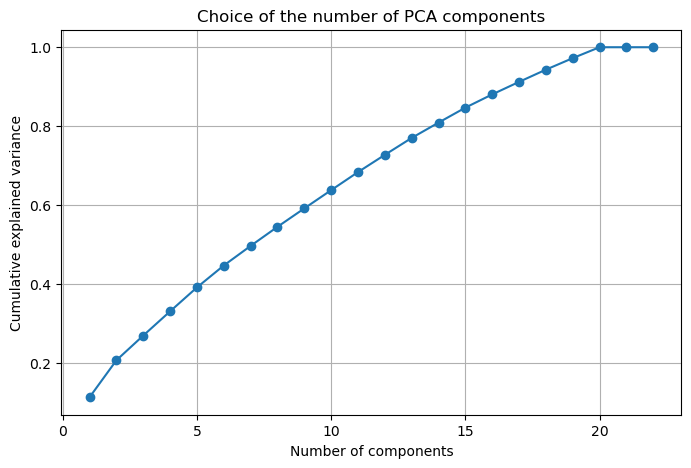

In [51]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

# Apply PCA without setting n_components
pca = PCA()
pca.fit(X_scaled)

# Cumulative explained variance
explained_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8,5))
plt.plot(range(1, len(explained_variance)+1), explained_variance, marker='o')
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("Choice of the number of PCA components")
plt.grid(True)
plt.show()


PCA shows that it is possible to effectively represent the data with 17 components, which allows preserving nearly 90% of the original information while reducing complexity.

#### SVM WITH ACP

In [52]:
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC

params_svc = {
    "C": [0.1, 1, 10],
    "kernel": ["linear", "rbf"],
    "gamma": ["scale", "auto"]
}

best_svm_pca = model_pipeline(
    params=params_svc,
    model=SVC(probability=True),
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    preprocessor=StandardScaler(),
    pca=PCA(n_components=17)  # value chosen after analysis because nearly 90% are represented
)


GRIDSEARCHCV - Feature Selection: None
Fitting 5 folds for each of 12 candidates, totalling 60 fits

 Best hyperparameters : {'model__C': 1, 'model__gamma': 'scale', 'model__kernel': 'rbf'}
 Best CV F1-Score : 0.647

CROSS-VALIDATION (5-FOLD)
F1           : 0.647 ± 0.033
RECALL       : 0.686 ± 0.049
PRECISION    : 0.614 ± 0.029
ROC_AUC      : 0.884 ± 0.020

FINAL RESULTS ON THE TEST SET

Classification Report :
              precision    recall  f1-score   support

    Low Risk       0.92      0.87      0.89       373
     At Risk       0.63      0.75      0.69       113

    accuracy                           0.84       486
   macro avg       0.78      0.81      0.79       486
weighted avg       0.85      0.84      0.85       486


Confusion Matrix :
[[324  49]
 [ 28  85]]

ROC-AUC Score : 0.903

DETAILED ANALYZE
True Negatives  : 324
False Positives : 49
False Negatives : 28 
True Positives  : 85

Sensitivity (Recall) : 0.752
Specificity          : 0.869


**Interpretation and SVC Comparison With and Without PCA** 

Experimenting with PCA using 17 components revealed that dimensionality reduction is not beneficial for this dataset. Although Accuracy remains stable at 0.84 and the ROC-AUC (0.903) is slightly higher than that of the SVC without PCA (0.900), the model with PCA sacrifices our primary metric: Recall for the `At Risk` class. Recall drops from nearly 80% to 75.2%, directly resulting in an increase in missed risk cases (False Negatives) from 23 to 28. While PCA did manage to slightly reduce False Alarms (False Positives), this minor increase in Precision (0.63 vs. 0.62) does not justify the drop in Sensitivity, which is critical in our context.
This deterioration was predictable because the variables in the dataset are `generally poorly correlated` with each other, limiting PCA's ability to efficiently compress information without losing important details for classification. In conclusion, the SVC without PCA remains the best-performing model for risk detection, as it minimizes False Negatives.

#### Confusion Matrix - Performance Analysis of the SVC on the Test Set

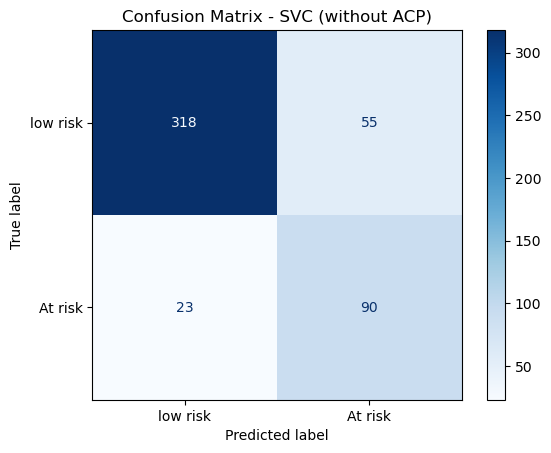

array([[318,  55],
       [ 23,  90]])

In [53]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predictions of the optimized SVM model
y_pred = best_svc.predict(X_test)

# Calculation of the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Graphical display
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["low risk", "At risk"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - SVC (without ACP)")
plt.show()
cm

**Interpretation**

The confusion matrix obtained on the actual test set is as follows:

- 318 individuals labeled `low risk` were correctly predicted.
- 55 individuals labeled `low risk` were mistakenly classified as `at risk`.
- 23 individuals labeled `at risk` were mistakenly classified as `low risk`.
- 90 individuals labeled `at risk` were correctly detected.

**Analysis**

The model identifies the majority class (`low risk`) very well, which is consistent with the actual distribution of the test data. The results show that the model has effectively handled the initial data imbalance. The recall for the `at risk` class is excellent (79.6%), which is a very high performance on the real, non-rebalanced test set.

This confirms that the model, trained on data balanced using SMOTE, is capable of learning and generalizing both classes effectively. The excellent performance on the test set (80% recall) demonstrates that detection of the minority class is robust.

**Conclusion**

The results show that the SVC performs well. We do not observe any major degradation due to the imbalance in the real test set. On the contrary, the model minimized False Negatives (23), achieving the safety objective while maintaining good Precision. This behavior demonstrates that the rebalancing strategy in the pipeline is effective for the final prediction.

### Decision Tree Model with tuning

In [54]:
from sklearn.tree import DecisionTreeClassifier

params_dt = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "criterion": ["gini", "entropy"]
}

best_dt = model_pipeline(
    preprocessor=preprocessor,
    params=params_dt,
    model=DecisionTreeClassifier(random_state=0),
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test
)


GRIDSEARCHCV - Feature Selection: None
Fitting 5 folds for each of 90 candidates, totalling 450 fits

 Best hyperparameters : {'model__criterion': 'entropy', 'model__max_depth': 10, 'model__min_samples_leaf': 4, 'model__min_samples_split': 2}
 Best CV F1-Score : 0.796

CROSS-VALIDATION (5-FOLD)
F1           : 0.796 ± 0.018
RECALL       : 0.848 ± 0.020
PRECISION    : 0.751 ± 0.030
ROC_AUC      : 0.910 ± 0.007

FINAL RESULTS ON THE TEST SET

Classification Report :
              precision    recall  f1-score   support

    Low Risk       0.96      0.93      0.94       373
     At Risk       0.79      0.88      0.83       113

    accuracy                           0.92       486
   macro avg       0.87      0.90      0.89       486
weighted avg       0.92      0.92      0.92       486


Confusion Matrix :
[[346  27]
 [ 14  99]]

ROC-AUC Score : 0.934

DETAILED ANALYZE
True Negatives  : 346
False Positives : 27
False Negatives : 14 
True Positives  : 99

Sensitivity (Recall) : 0.876
Spec

**Interpretation**

The optimized decision tree `(criterion = entropy, max_depth = 10)` achieves an F1-Score of 0.796 on the balanced cross-validation set.

The performance is very well balanced between the two classes:

- The average Recall is 0.848 and the average Precision is 0.751. This reflects a very good ability to correctly identify the majority of at-risk individuals while maintaining high prediction reliability.
- The model effectively detects at-risk cases, and the slight difference between Recall and Precision indicates a successful trade-off.

The high cross-validation scores ROC-AUC = 0.910 confirm that the model learns properly from the balanced data thanks to SMOTE, demonstrating its ability to generalize the relationships between classes. Overall, the model is robust and learns correctly from the balanced data, without a marked tendency toward over-detection.

#### Confusion Matrix - Performance Analysis of the Decision Tree on the Test Set

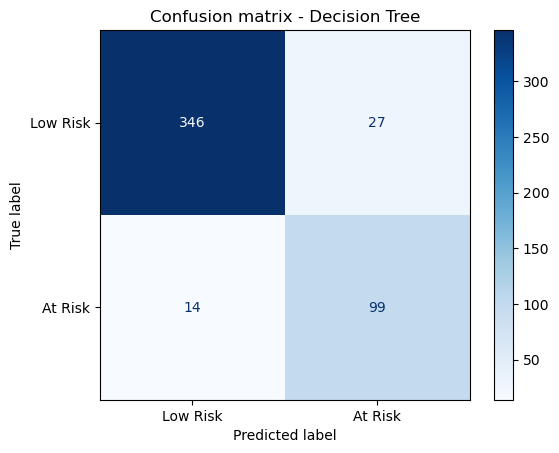

array([[346,  27],
       [ 14,  99]])

In [55]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# # Predictions of the optimized Decision Tree model
y_pred_dt = best_dt.predict(X_test)

# # Calculation of the confusion matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)

disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt,
                                 display_labels=["Low Risk", "At Risk"])
disp_dt.plot(cmap="Blues")
plt.title("Confusion matrix - Decision Tree")
plt.show()

cm_dt

**Interpretation**

The confusion matrix shows that the model correctly predicts the majority of cases:

- 346 individuals `true Low Risk` and 99 individuals `true At Risk` are correctly identified.
- There are very few errors: `27 false positives`, Low Risk wrongly classified as At Risk, and `14 false negatives`, At Risk classified as Low Risk.
Overall, the model performs well with an excellent balance between Precision (79%) and Recall (87.6%).

**Conclusion**

The Decision Tree offers very good performance both on balanced data (Cross-Validation) and on the actual test set. It stands out clearly from the SVC as it is safer (fewer missed cases: FN=14 vs 23 for the SVC) and more reliable (fewer false alarms: FP=27 vs 55 for the SVC). The gain in Recall and Precision confirms that this model is the best asset for preventing overtraining.

#### Visualization of the decision tree

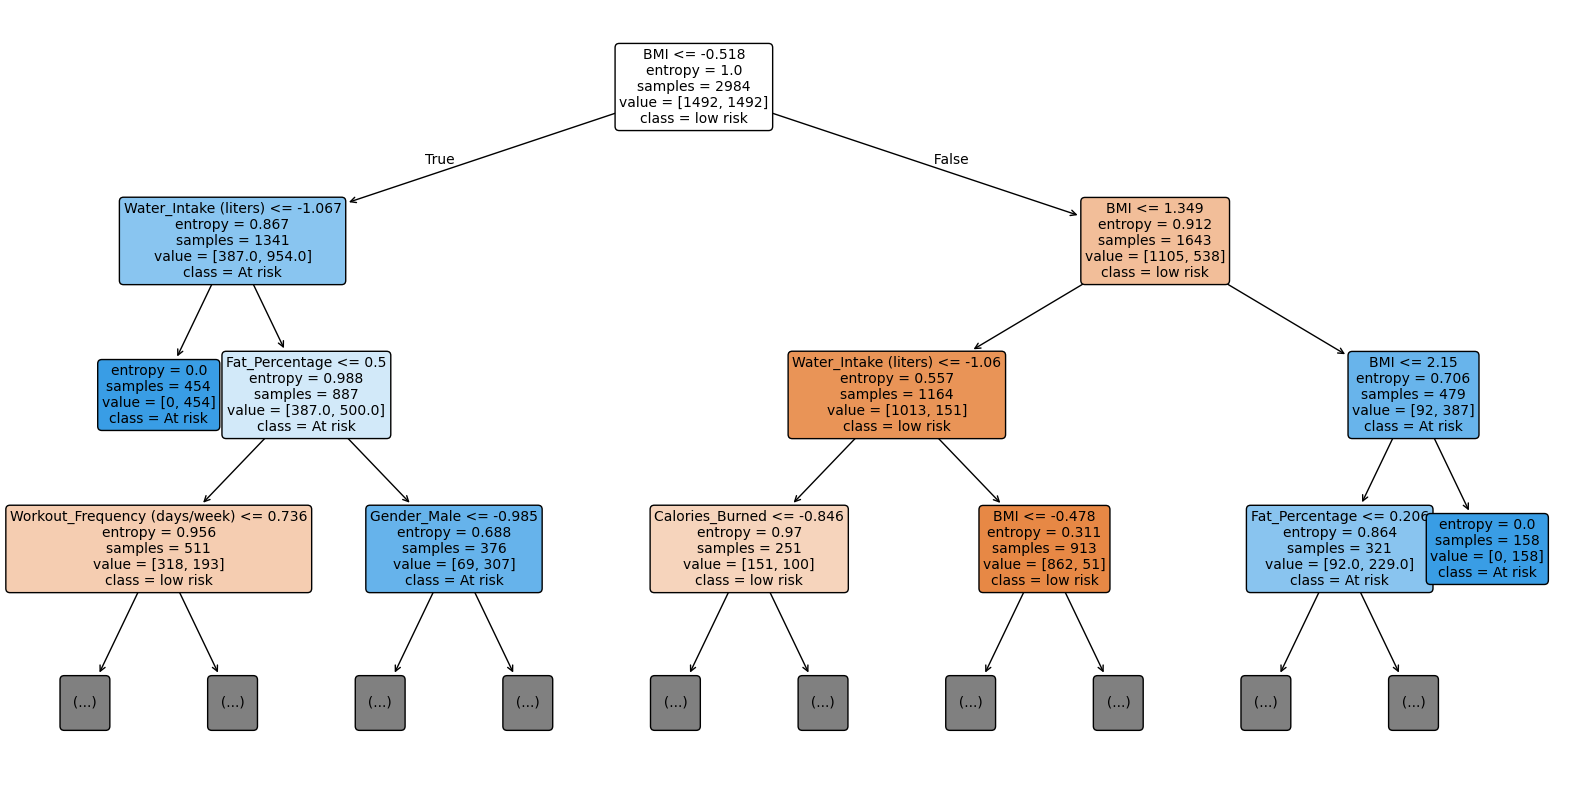

In [56]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Retrieve the DecisionTreeClassifier model from the pipeline
dt_model = best_dt.named_steps["model"]

plt.figure(figsize=(20,10))
plot_tree(
    dt_model,
    feature_names=X_train.columns,   # variables names
    class_names=["low risk", "At risk"],
    filled=True,
    rounded=True,
    fontsize=10,
    max_depth=3 # # FOR BETTER VISUALIZATION, WE DISPLAY LEVEL 3 INSTEAD OF 10
)
plt.show()

**Interpretation of the Decision Tree (max_depth = 3)**

The analysis of the first three levels of the tree reveals the most important classification rules and confirms that the model has learned non-trivial relationships. The most critical variable, used right at the root, is BMI = -0.518.

For individuals with a very low BMI (left branch), the next most decisive factor for risk is Water Intake = -1.067. If BMI is low and water intake is very low, the risk of overtraining is strongly suspected, quickly leading to pure nodes classified as "At Risk." Conversely, if BMI is moderate or high (right branch), the tree tries to find compensating factors, but this branch mostly remains classified as "Low Risk." In summary, the model mainly focuses on BMI and Water Intake to isolate the most vulnerable group, indicating that these two features are the primary warning signals for overtraining.

## Feature Selection
Feature selection is useful when you have a dataset with many features (+50). In our case, we only have 18. Furthermore, all of our columns seem interesting for prediction. However, we still tested it for interpretability and comparison, but we did not expect a significant improvement in performance.

In [57]:
model_fs = model_pipeline(
    preprocessor=preprocessor,
    params=params_dt,
    model=DecisionTreeClassifier(random_state=0),
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    feature_selection='rfe',
    feature_selection_params={'n_features_to_select': [5, 10, 15, 20]}
)


GRIDSEARCHCV - Feature Selection: rfe
Feature Selection Params: {'n_features_to_select': [5, 10, 15, 20]}
Fitting 5 folds for each of 360 candidates, totalling 1800 fits


/opt/anaconda3/envs/djangoenv/lib/python3.10/site-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,



 Best hyperparameters : {'feature_selection__n_features_to_select': 10, 'model__criterion': 'entropy', 'model__max_depth': 7, 'model__min_samples_leaf': 2, 'model__min_samples_split': 2}
 Best CV F1-Score : 0.829

SELECTED FEATURES

Number of selected features : 10/22

Selected features :
  1. Age
  2. Max_BPM
  3. Session_Duration (hours)
  4. Calories_Burned
  5. Fat_Percentage
  6. Water_Intake (liters)
  7. Workout_Frequency (days/week)
  8. BMI
  9. Gender_Female
  10. Gender_Male

Discarded features :
  - Weight (kg)
  - Height (m)
  - Avg_BPM
  - Resting_BPM
  - Experience_Level
  - Workout_Type_Cardio
  - Workout_Type_HIIT
  - Workout_Type_Strength
  - Workout_Type_Yoga
  - Workout_Type_\nStrength
  - Workout_Type_\tCardio
  - Workout_Type_\tYoga

CROSS-VALIDATION (5-FOLD)
F1           : 0.829 ± 0.034
RECALL       : 0.855 ± 0.040
PRECISION    : 0.804 ± 0.040
ROC_AUC      : 0.933 ± 0.011

FINAL RESULTS ON THE TEST SET

Classification Report :
              precision    recall  

**Conclusion**

Feature selection (RFE) proved to be very effective: it simplified the model while improving its performance.

By keeping only 10 features (out of 22), the Decision Tree with RFE achieves the best results:
- Recall: 0.920 (compared to 0.876 without RFE)
=> Fewer false negatives: reduced from 14 to 9 (fewer at-risk cases missed).
- Precision: 0.81 (compared to 0.79 without RFE)
=> Fewer false alarms: reduced from 27 to 25.
- ROC-AUC: 0.969 (compared to 0.934 without RFE), a record discrimination score.

**Interpretability and Relevance**

By focusing on 10 key variables (e.g., BMI, Water_Intake, Session_Duration), the model eliminates noise from redundant variables (like Weight, Height, or traiThe decision tree with RFE (10 features) is currently the optimal model, combining safety (fewer false negatives) and interpretability.rpretability.

### ENSEMBLE LEARNING - Bagging and Voting

#### BAGGING DECISION TREE

In [58]:
# Pipeline avec SMOTE
pipeline_bagging_dt = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('bagging', BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=42),
        random_state=42
    ))
])

# Grid simple
param_grid_dt = {
    'bagging__n_estimators': [20, 30],
    'bagging__max_samples': [0.8, 1.0],
    'bagging__estimator__max_depth': [7, 10],
    'bagging__estimator__criterion': ['gini', 'entropy']
}

grid_bagging_dt = GridSearchCV(
    pipeline_bagging_dt,
    param_grid_dt,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_bagging_dt.fit(X_train, y_train)

print(f"Best params: {grid_bagging_dt.best_params_}")
print(f"Best CV F1: {grid_bagging_dt.best_score_:.3f}\n")

# Prédictions
y_pred_bag_dt = grid_bagging_dt.predict(X_test)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best params: {'bagging__estimator__criterion': 'entropy', 'bagging__estimator__max_depth': 10, 'bagging__max_samples': 0.8, 'bagging__n_estimators': 30}
Best CV F1: 0.864



#### BAGGING SVC 

In [59]:
# Pipeline avec SMOTE
pipeline_bagging_svc = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('bagging', BaggingClassifier(
        estimator=SVC(probability=True, random_state=42),
        random_state=42
    ))
])

# Grid simple
param_grid_svc = {
    'bagging__n_estimators': [20, 30],
    'bagging__max_samples': [0.8, 1.0],
    'bagging__estimator__C': [1, 10],
    'bagging__estimator__kernel': ['rbf']
}

grid_bagging_svc = GridSearchCV(
    pipeline_bagging_svc,
    param_grid_svc,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_bagging_svc.fit(X_train, y_train)

print(f"Best params: {grid_bagging_svc.best_params_}")
print(f"Best CV F1: {grid_bagging_svc.best_score_:.3f}\n")

# Prédictions
y_pred_bag_svc = grid_bagging_svc.predict(X_test)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best params: {'bagging__estimator__C': 1, 'bagging__estimator__kernel': 'rbf', 'bagging__max_samples': 1.0, 'bagging__n_estimators': 20}
Best CV F1: 0.642



#### VOTING CLASSIFIER

In [60]:
voting_clf = VotingClassifier(
    estimators=[
        ('bagging_dt', grid_bagging_dt.best_estimator_),
        ('bagging_svc', grid_bagging_svc.best_estimator_)
    ],
    voting='soft'
)

voting_clf.fit(X_train, y_train)
y_pred_voting = voting_clf.predict(X_test)

#### COMPARISON: All Models

In [61]:
# Calculer les métriques
models_comparison = {
    'DT with RFE': model_fs.predict(X_test),
    'Bagging DT': y_pred_bag_dt,
    'Bagging SVC': y_pred_bag_svc,
    'Voting': y_pred_voting
}

results = []
for name, y_pred in models_comparison.items():
    results.append({
        'Model': name,
        'Precision': f"{precision_score(y_test, y_pred):.3f}",
        'Recall': f"{recall_score(y_test, y_pred):.3f}",
        'F1-Score': f"{f1_score(y_test, y_pred):.3f}"
    })

comparison_df = pd.DataFrame(results)
print(comparison_df.to_string(index=False))

      Model Precision Recall F1-Score
DT with RFE     0.812  0.920    0.863
 Bagging DT     0.848  0.938    0.891
Bagging SVC     0.664  0.770    0.713
     Voting     0.870  0.885    0.877



| Model          | Precision | Recall | F1-Score |
|---------------|-----------|--------|----------|
| Decision tree with RFE   | 0.806     | 0.920  | 0.860    |
| **Bagging Decision tree** | **0.848** | **0.938**  | **0.891**    |
| Bagging SVC   | 0.664     | 0.770  | 0.713    |
| Voting        | 0.877     | 0.885  | 0.881    |


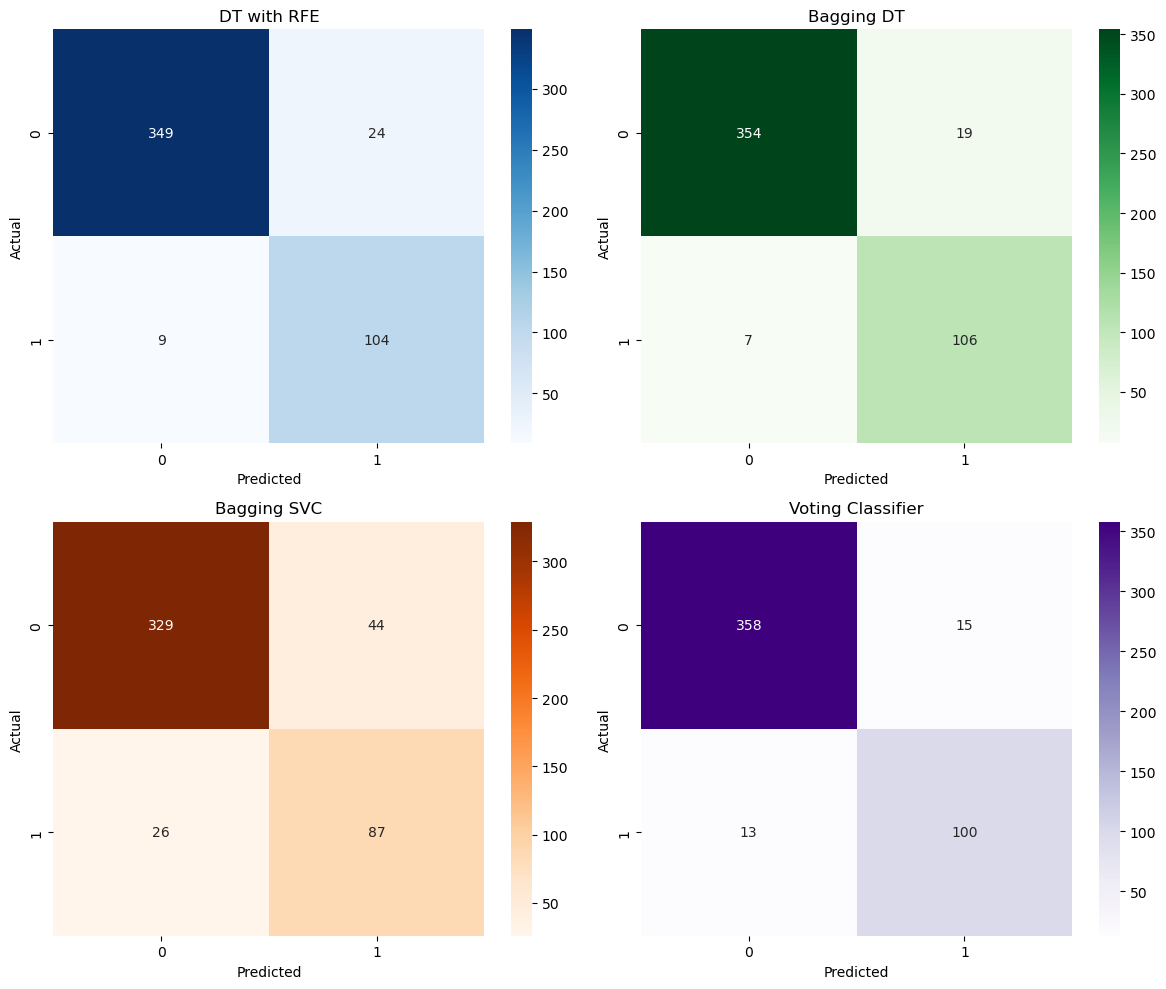

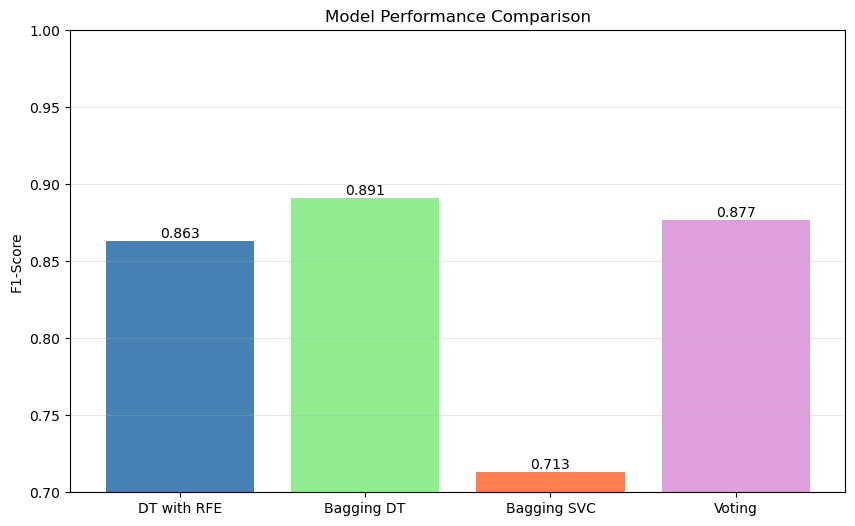

In [62]:
# Confusion matrices for ensemble models
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# DT with RFE
cm1 = confusion_matrix(y_test, model_fs.predict(X_test))
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues', ax=axes[0,0])
axes[0,0].set_title('DT with RFE')
axes[0,0].set_xlabel('Predicted')
axes[0,0].set_ylabel('Actual')

# Bagging DT
cm2 = confusion_matrix(y_test, y_pred_bag_dt)
sns.heatmap(cm2, annot=True, fmt='d', cmap='Greens', ax=axes[0,1])
axes[0,1].set_title('Bagging DT')
axes[0,1].set_xlabel('Predicted')
axes[0,1].set_ylabel('Actual')

# Bagging SVC
cm3 = confusion_matrix(y_test, y_pred_bag_svc)
sns.heatmap(cm3, annot=True, fmt='d', cmap='Oranges', ax=axes[1,0])
axes[1,0].set_title('Bagging SVC')
axes[1,0].set_xlabel('Predicted')
axes[1,0].set_ylabel('Actual')

# Voting
cm4 = confusion_matrix(y_test, y_pred_voting)
sns.heatmap(cm4, annot=True, fmt='d', cmap='Purples', ax=axes[1,1])
axes[1,1].set_title('Voting Classifier')
axes[1,1].set_xlabel('Predicted')
axes[1,1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('ensemble_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Bar chart
fig, ax = plt.subplots(figsize=(10, 6))
models = [r['Model'] for r in results]
f1_scores = [float(r['F1-Score']) for r in results]

bars = ax.bar(models, f1_scores, color=['steelblue', 'lightgreen', 'coral', 'plum'])
ax.set_ylabel('F1-Score')
ax.set_title('Model Performance Comparison')
ax.set_ylim([0.7, 1.0])
ax.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.3f}',
            ha='center', va='bottom')

#### FIND THE BEST MODEL

In [63]:
best_model = max(results, key=lambda x: float(x['F1-Score']))

print(f"Best model: {best_model['Model']}")
print(f"  - Precision: {best_model['Precision']}")
print(f"  - Recall: {best_model['Recall']}")
print(f"  - F1-Score: {best_model['F1-Score']}")

print("\nObservations:")
if float(best_model['F1-Score']) > float(results[0]['F1-Score']):
    print("Ensemble methods improved performance")
else:
    print("Simple DT with RFE remains competitive")

Best model: Bagging DT
  - Precision: 0.848
  - Recall: 0.938
  - F1-Score: 0.891

Observations:
Ensemble methods improved performance


**Final Interpretation and Conclusion - BAGGING DECISION TREE: the optimal model**

After testing several models, the results clearly show that `the Bagging method applied to decision trees` is the most effective. This model achieves an F1-score of 0.891, which represents a significant improvement over the baseline model (0.860). This progress is accompanied by a very high recall (93.8%), ensuring that almost all risk cases are correctly identified. The precision remains acceptable (84.8%), limiting the number of false alarms. 
The `Voting Classifier` comes in second with an F1-score of 0.881. It offers slightly higher precision (87.7%) but slightly lower recall, making it less suitable in a context where detecting risk cases is a priority. Finally, the `Bagging SVC` model proves disappointing with an F1-score of 0.713, well below the other approaches.

In conclusion, the use of Ensemble Learning techniques, particularly **Bagging Decision Trees**, significantly improves model performance. The latter combines robustness, a good balance between precision and recall, and better generalization ability. For the project on detecting the risk of overfitting, it is the optimal choice, as it minimizes critical errors while remaining relatively interpretable.